# This section covers : "Who is actually responsible for deciding whether that data is still true and allowed to be retrieved?"**

## SUMMARY:
# <summary>
1. Source of truth
   → authoritative system for current data/state

2. Vector index
   → retrieval projection/cache, NOT canonical truth

3. Lineage
   → ability to trace a vector back to its source and processing history

4. Chunker version
   → identifies which chunking logic produced the vector

5. Embedding pipeline version
   → identifies which embedding pipeline generated it

6. Incremental sync
   → update only changed records

7. Query-time resolution
   → retrieve candidates, then verify current state/permissions from the source

8. Delete propagation
   → source deletion must reach the vector index</summary>

## The Core Idea :
 - #### **The vector database is not the source of truth. It is a retrieval-optimized projection/cache of the source systems.**


<pre>SOURCE OF TRUTH
               ┌─────────────────────┐
               │ CMS / DB / Warehouse│
               │ S3 / SharePoint etc │
               └──────────┬──────────┘
                          │
                    ingestion
                          ↓
                 chunk + embed
                          ↓
                  ┌──────────────┐
                  │ Vector Store │
                  └──────────────┘
                          │
                    retrieval
                          ↓
                        App</pre>

## The source system says:
- "This document is currently version 7 and the user no longer has access."

The vector DB shouldn't be allowed to independently invent a different reality.                      

# 2. "Source of truth" — the terminology you need
<pre>Source of truth means:
The system that has authoritative ownership over the current state of the data.

It isn't necessarily one particular technology.
It could be:
Snowflake
PostgreSQL
SharePoint
Confluence
S3
A CMS
Operational database

The important question isn't:
"Which database is better?"

It's:
"Which system has the authority to say that this record has changed, been deleted, or is no longer accessible?"

That's the system your vector index has to follow.</pre>



# 3. What does the vector DB actually own?
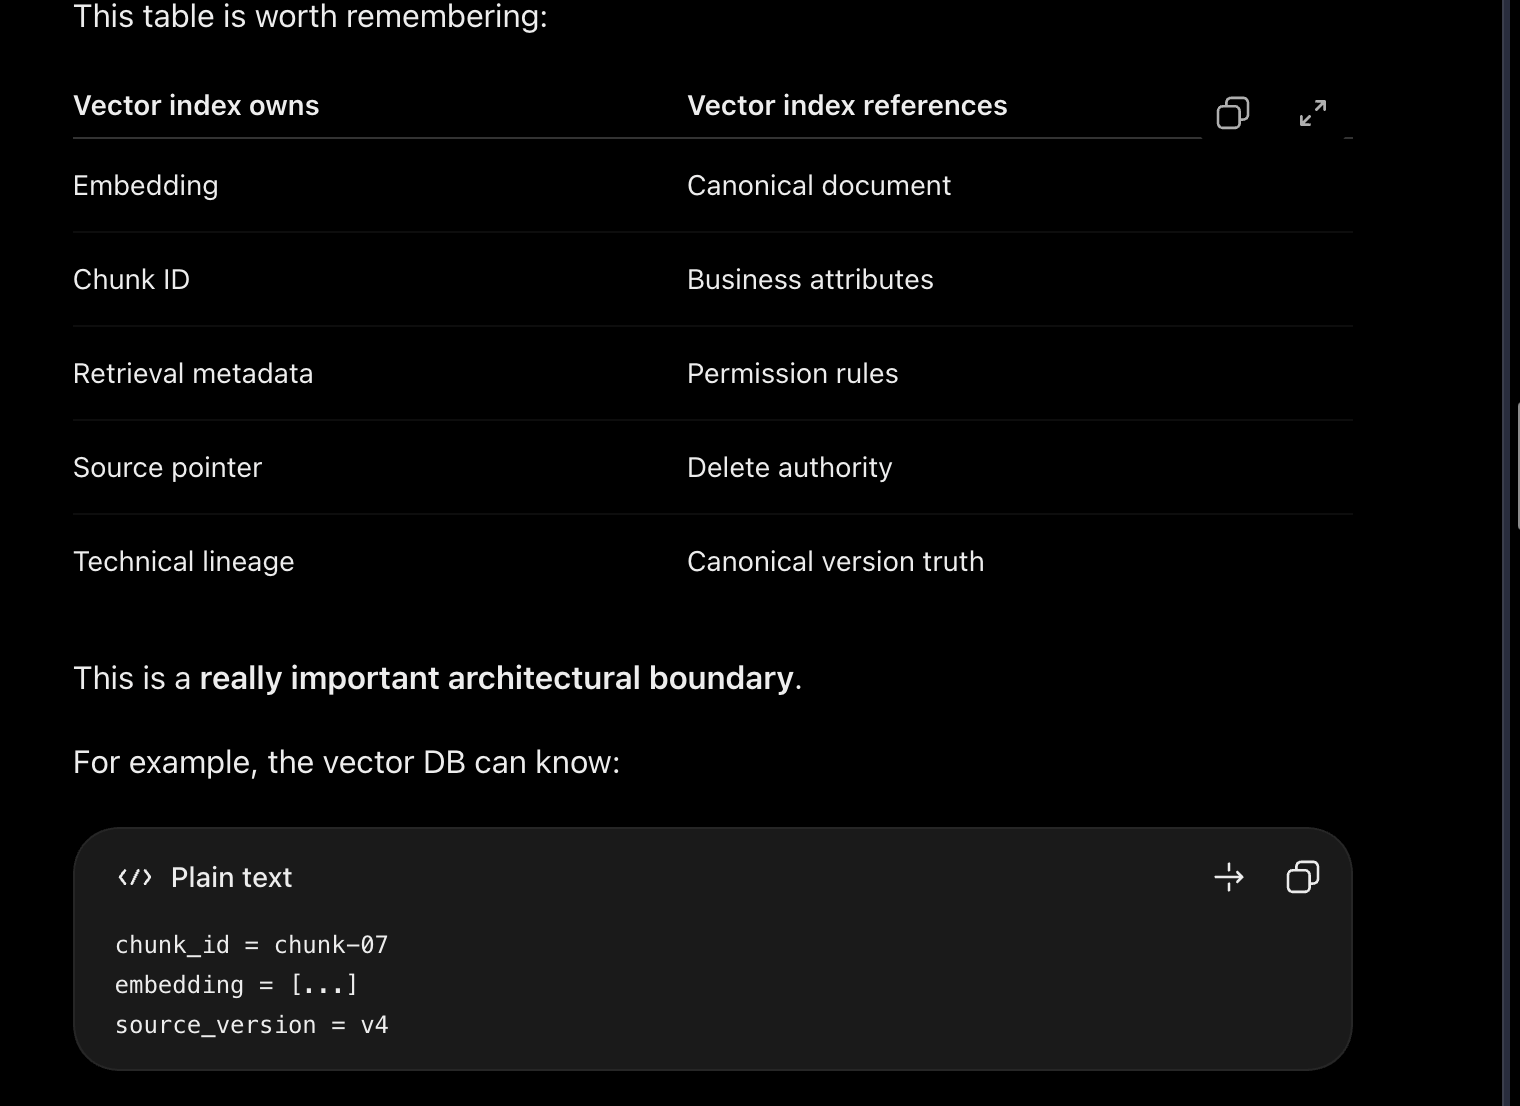
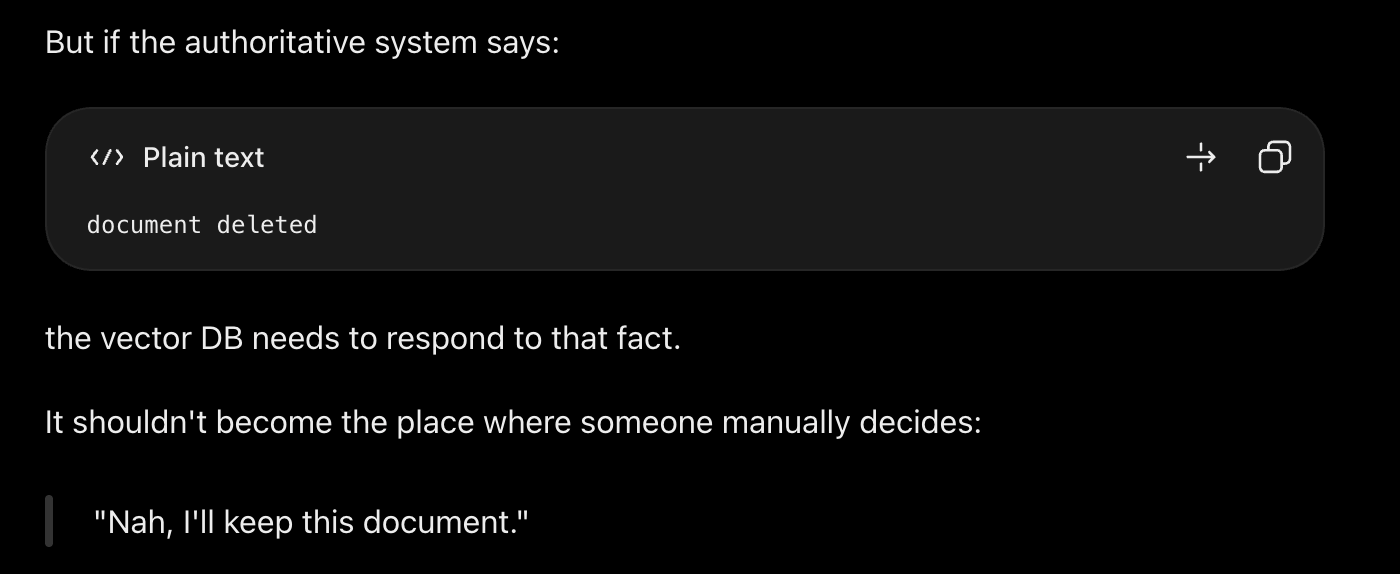


# 4. Lineage
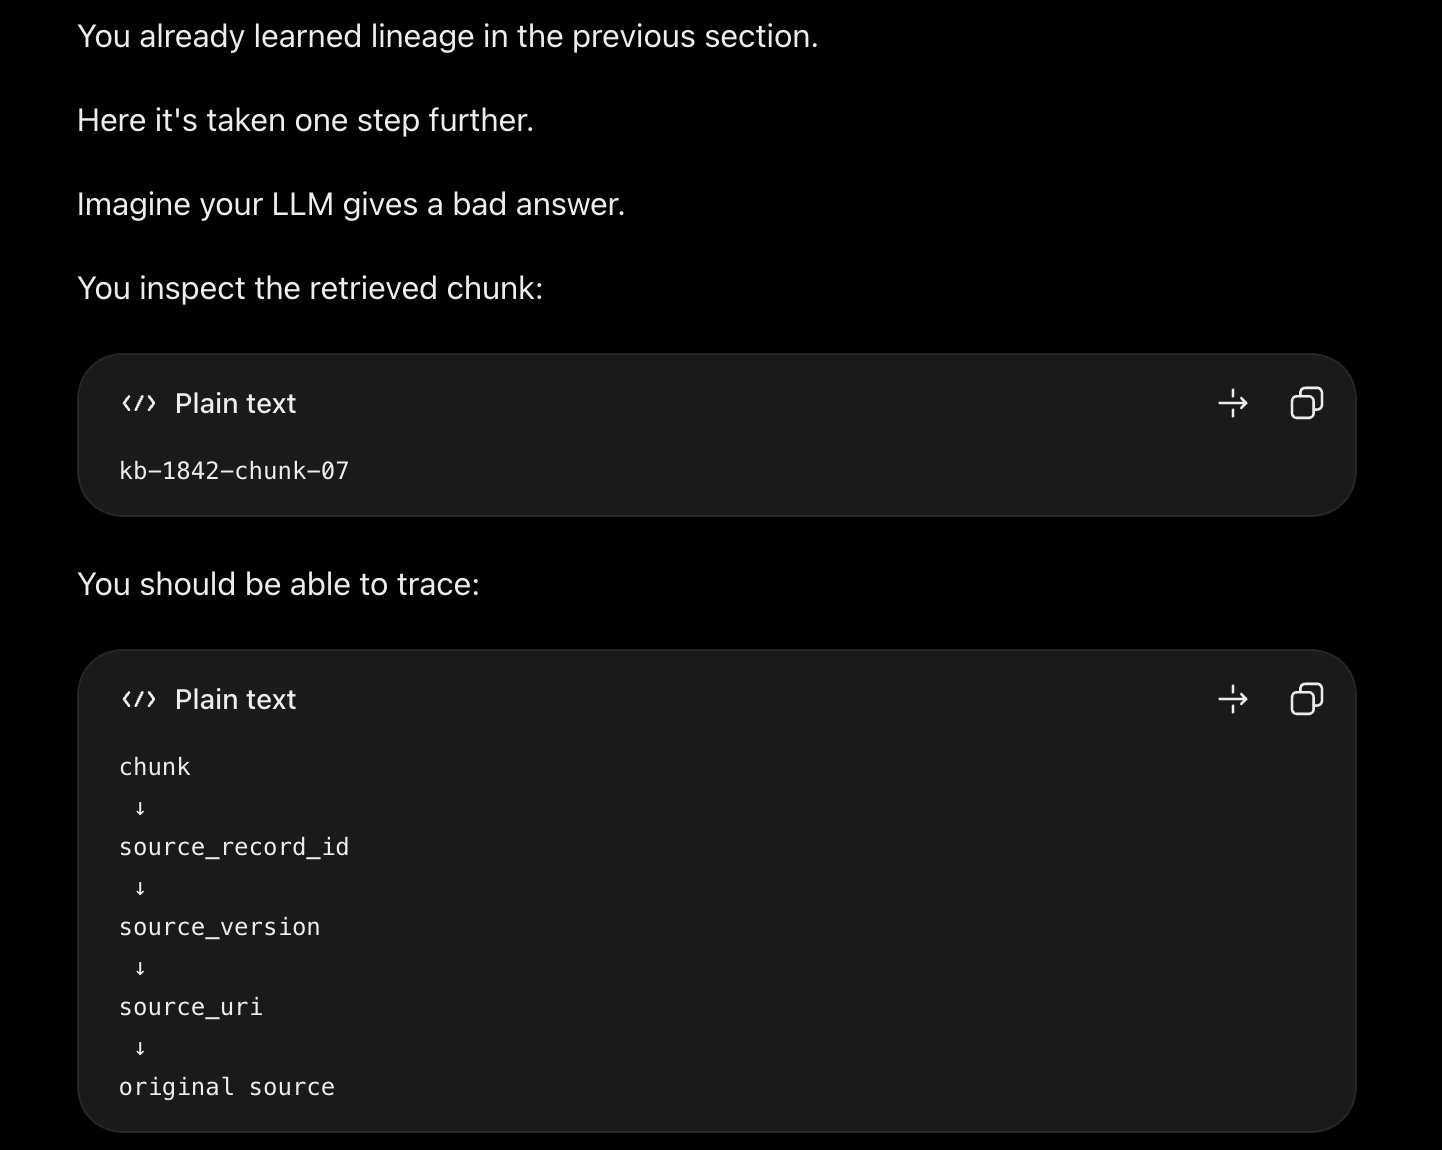
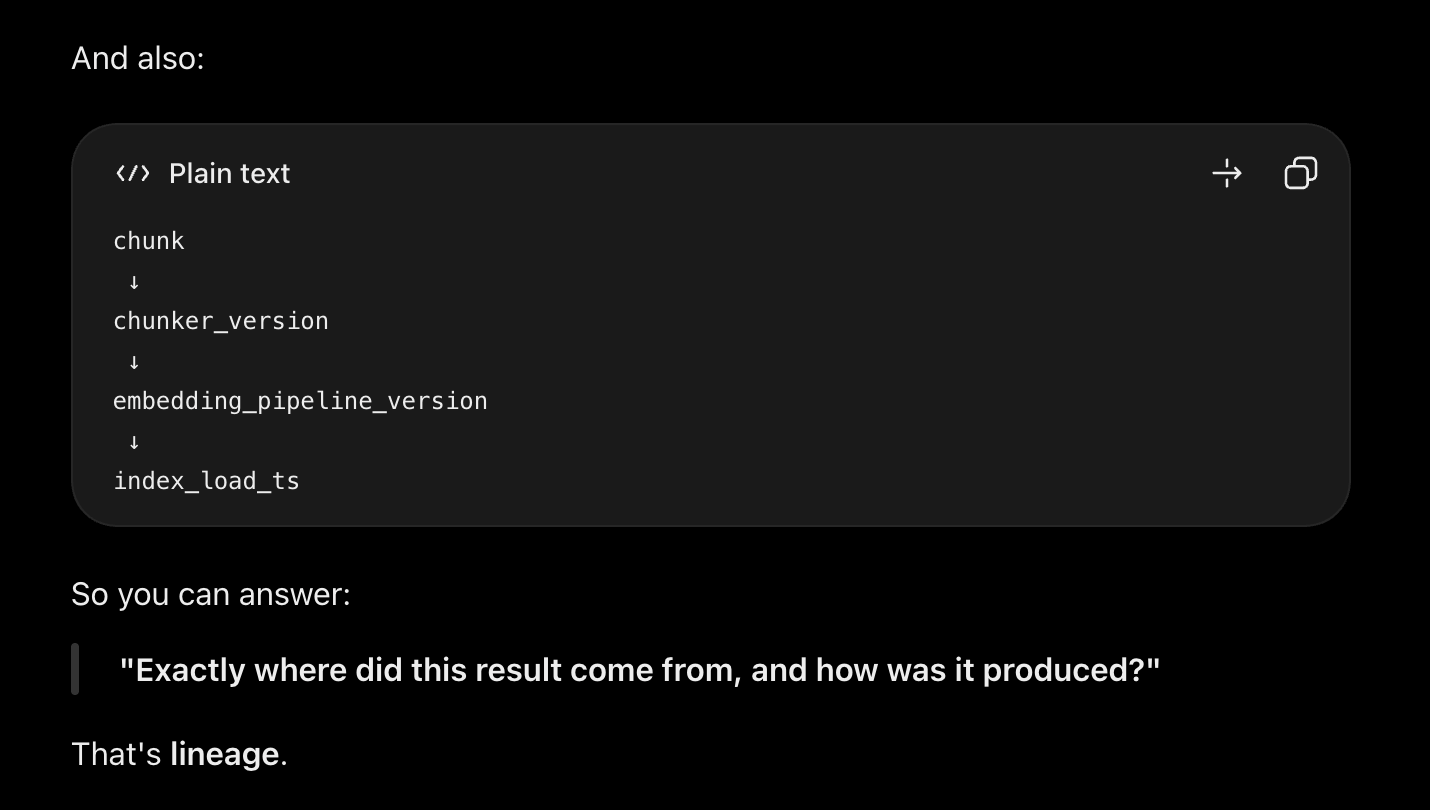


# 5. The new terminology:
# a). chunker_version
<pre>This one is worth understanding.
Suppose originally you chunked documents using:
1000-token chunks

Then you change your algorithm to:
heading-aware 800-token chunks

Now the same document produces completely different chunks.
Therefore:
chunker_version = v1

versus:
chunker_version = v2

helps you determine whether a retrieval change came from the chunking strategy rather than the source content or embedding model.</pre>

# B.) embedding_pipeline_version
<pre>Same idea.
Suppose:
Pipeline v1
    ↓
Embedding model A

Later:
Pipeline v2
    ↓
Embedding model B

Your retrieval behavior can change.
If you don't record the pipeline version, debugging becomes:
"Why the fuck did retrieval suddenly get worse?"

😂
With lineage:
Query
 ↓
Bad result
 ↓
embedding_pipeline_version = v2
 ↓
"We changed the embedding pipeline yesterday."

Now you have evidence.</pre>


# 6.The four integration patterns
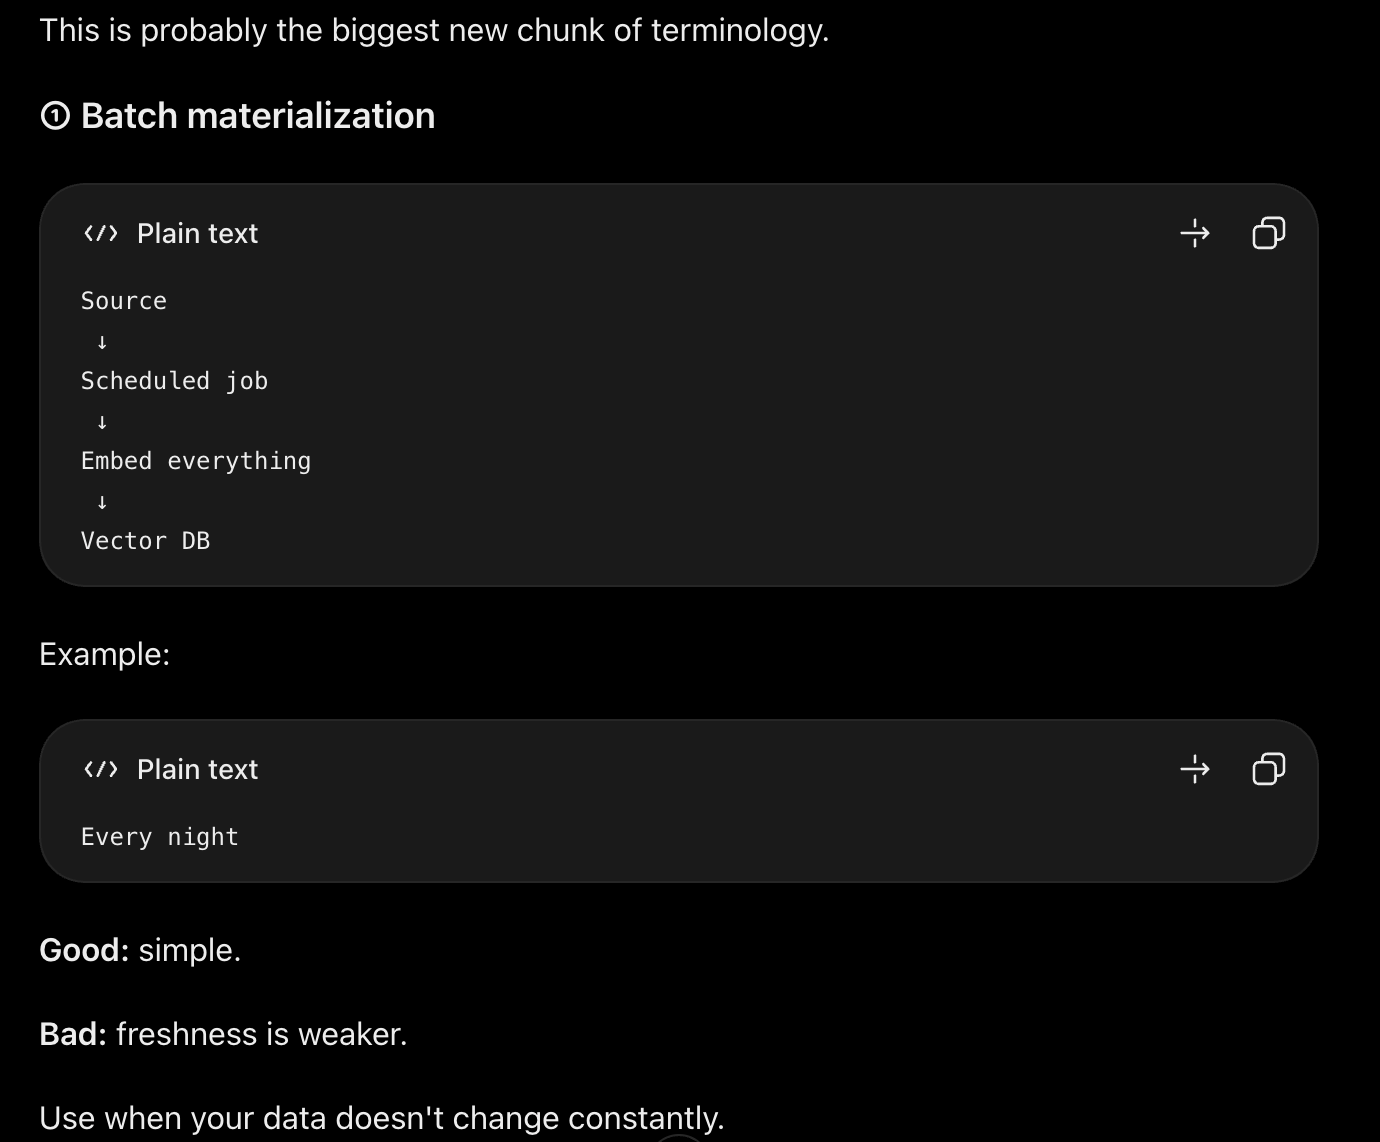
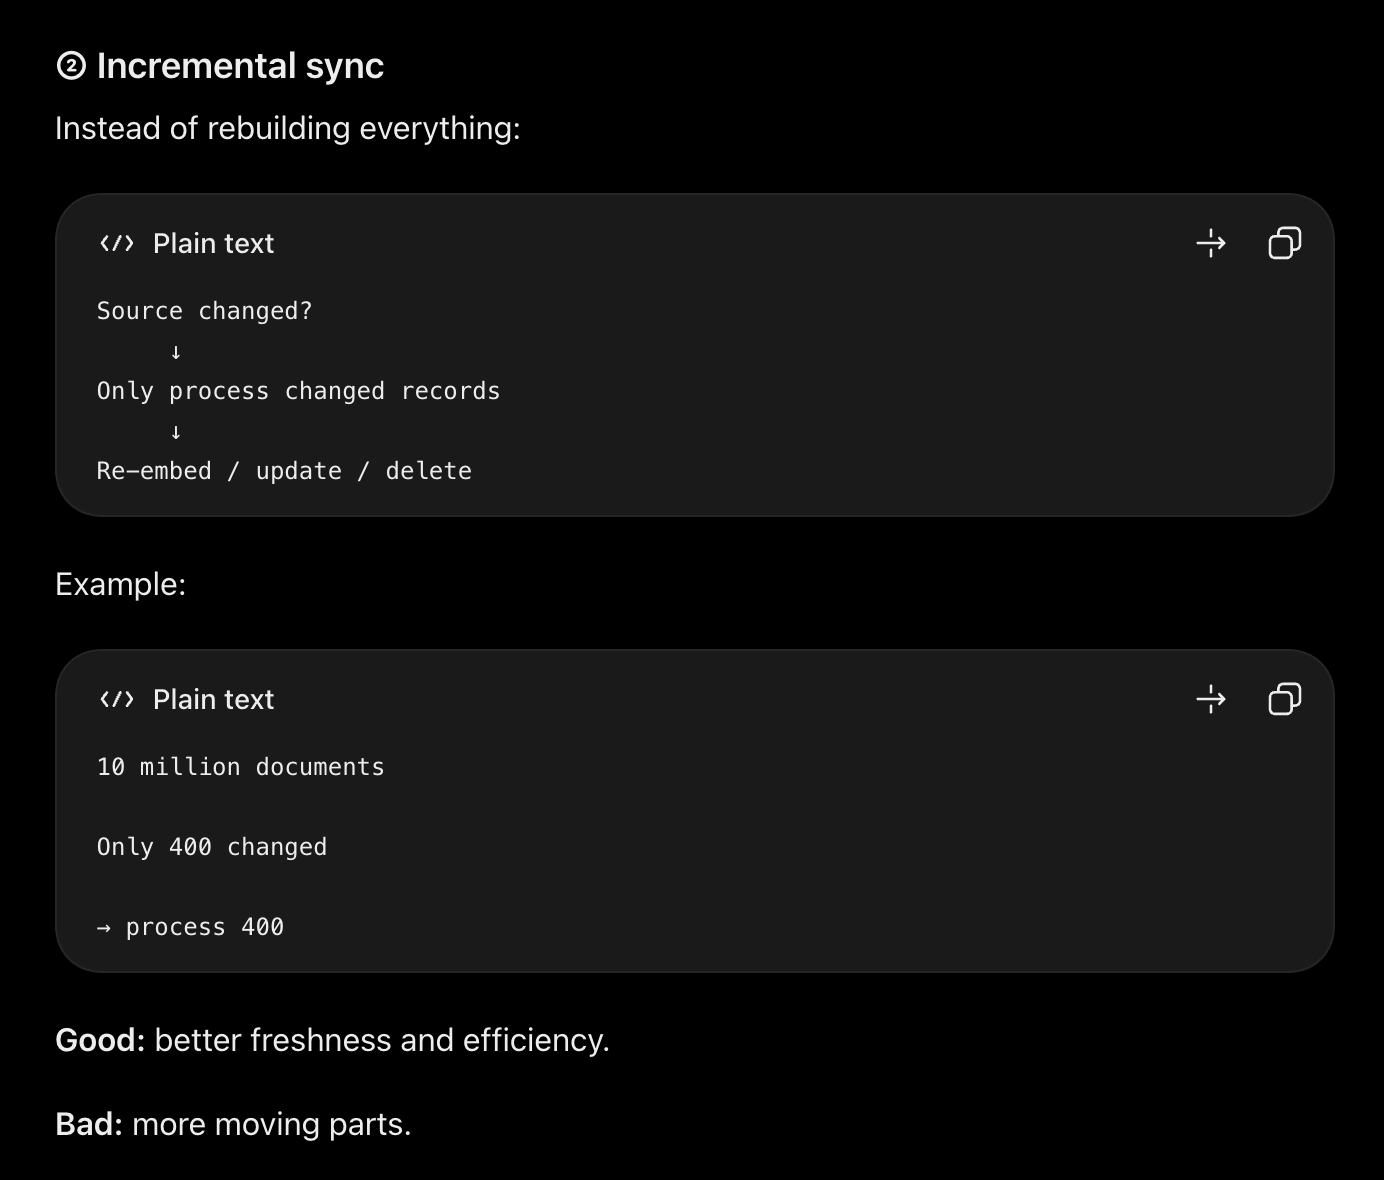
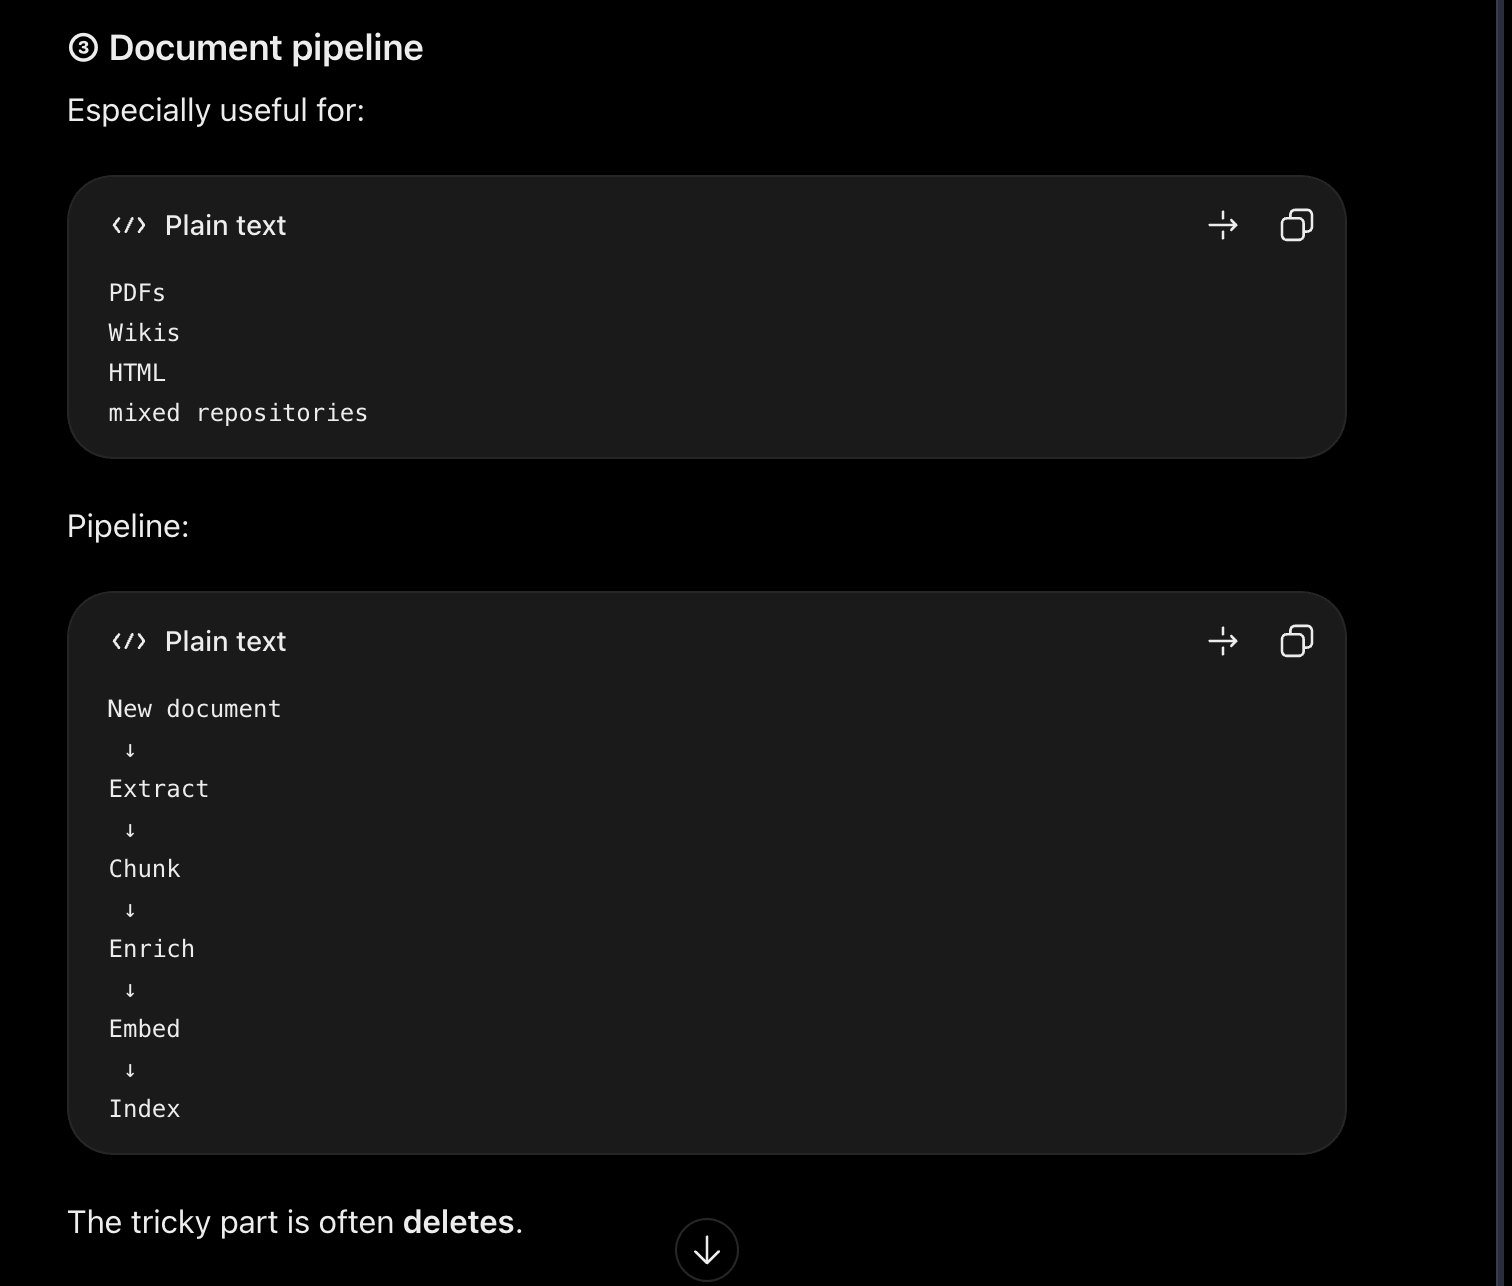
# **IMPORTANT FOR SECURITY**
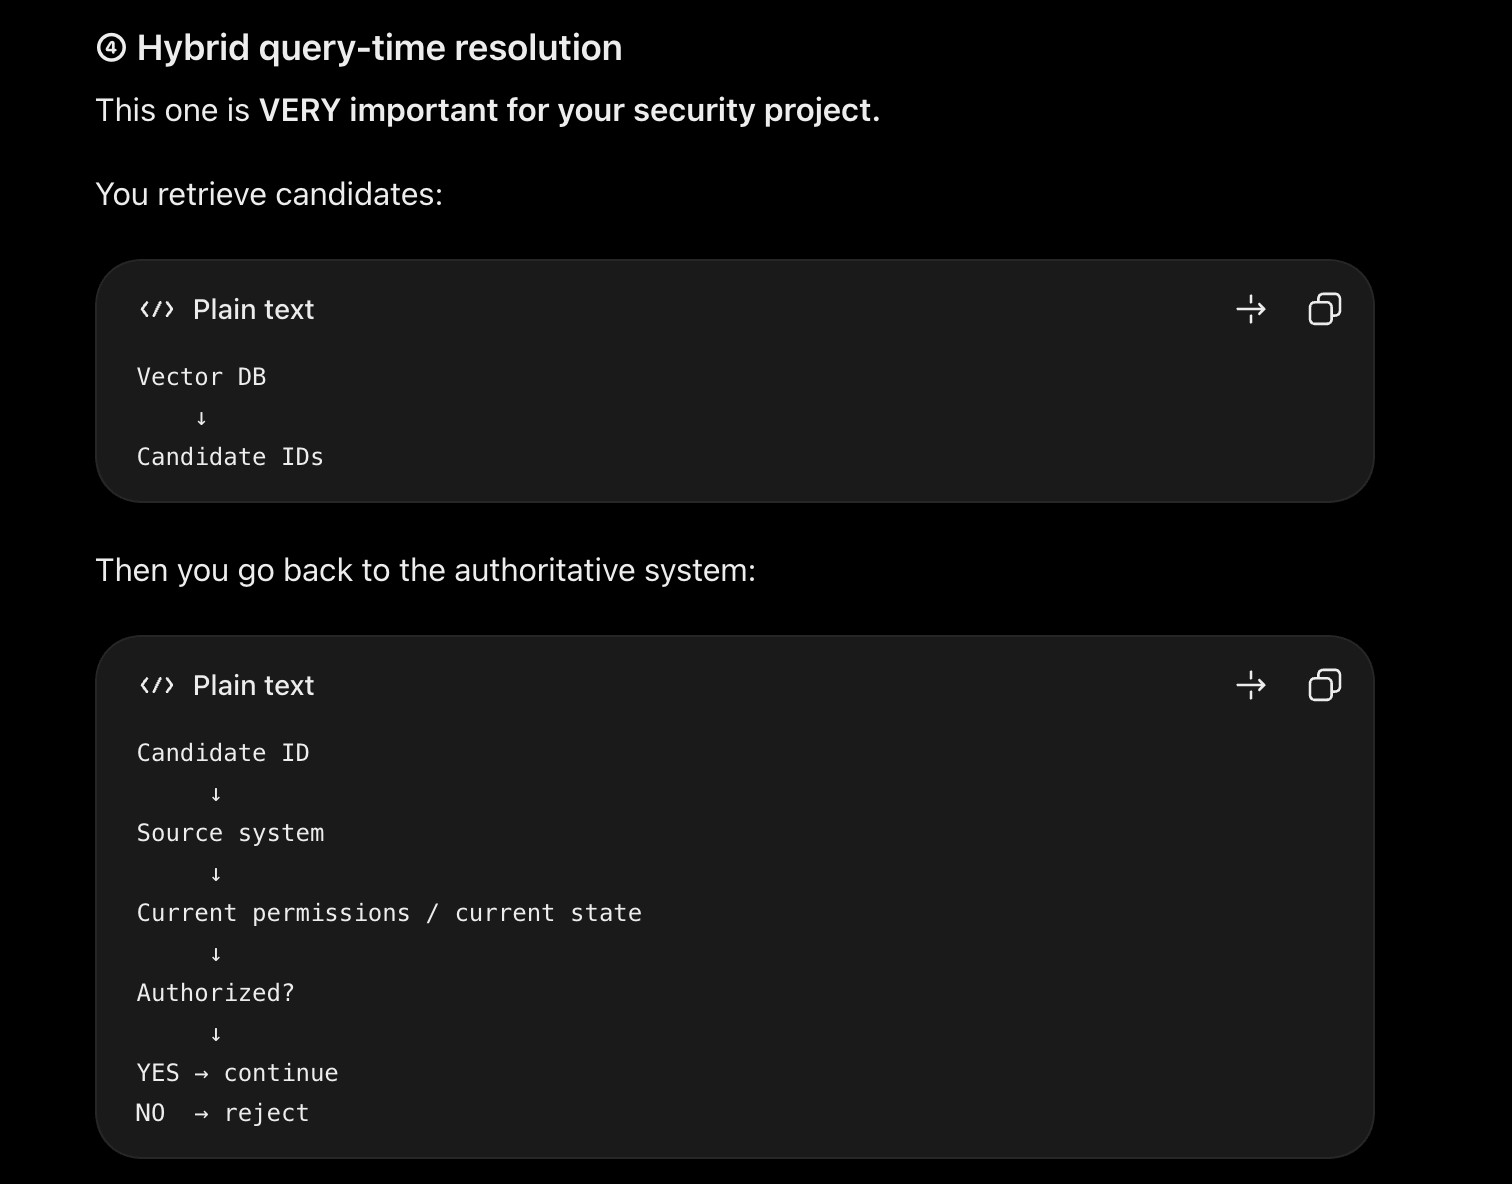
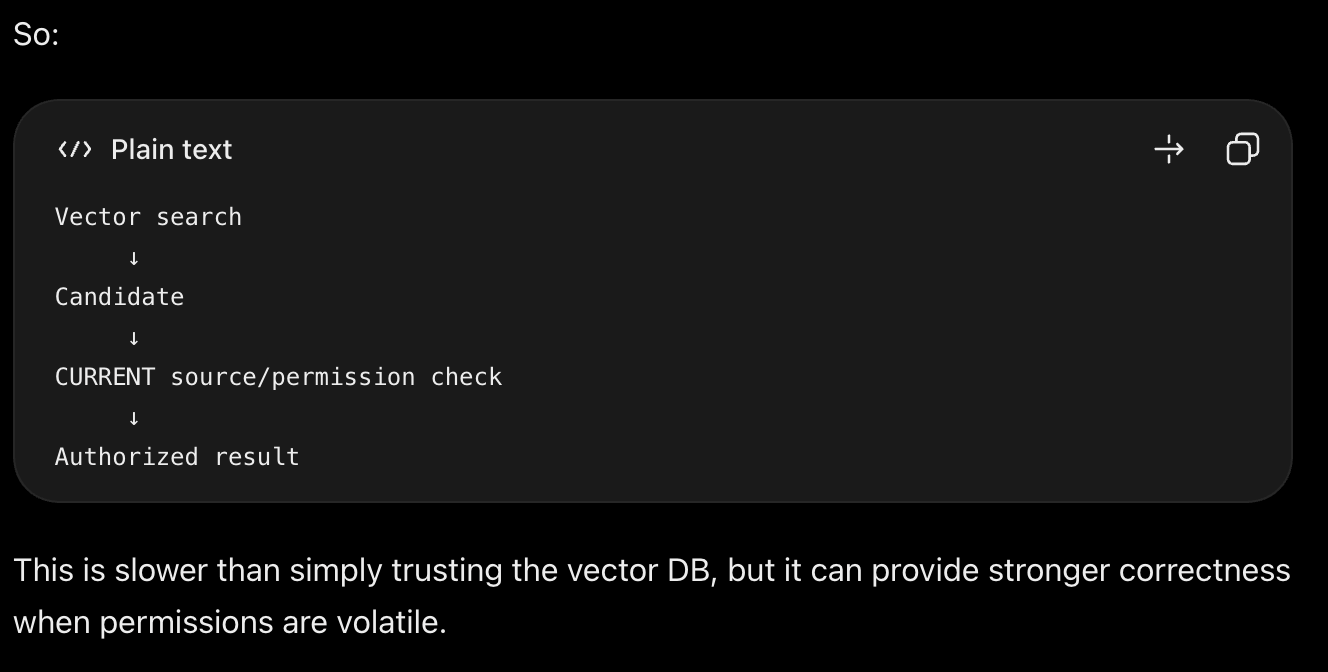

# 7. This connects DIRECTLY to your pre-filter/post-filter question
<pre>
Remember the slide you showed me?
Pre-filter
Permission filter
       ↓
Vector search

Post-filter
Vector search
       ↓
Permission filter

This section gives you another possibility:
Query-time resolution
Vector search
       ↓
Candidate IDs
       ↓
Authoritative source system
       ↓
Current permission/state
       ↓
Final authorized results

This is why the course says:
If permissions are volatile, don't assume pre-index filtering is enough.

Because imagine:
10:00 AM
User has access

10:05 AM
Permission revoked

10:06 AM
User searches

If your vector metadata still says:
access = allowed

then a stale index can potentially return something the user should no longer see.
Query-time resolution lets you ask the authoritative system:
"What is the user's permission right now?"

That's a much stronger security boundary.</pre>

# 8. Deletes are actually a huge deal
<pre>The course makes a very good point:
Inserts are easy. Deletes are where systems often break.

Imagine:
Source DB

doc-101 → exists

You index it:
Vector DB

doc-101 → exists

Then someone deletes it from the source:
Source DB

doc-101 → ❌ deleted

But nobody tells the vector DB.
Now:
Vector DB

doc-101 → STILL EXISTS

User searches.
Retriever finds it.
💀
That's an orphaned chunk.
So your system needs explicit delete propagation:
Source deleted
      ↓
Detect deletion
      ↓
Delete/tombstone vector
      ↓
No longer retrievable</pre>

# 9. The failure modes to remember 
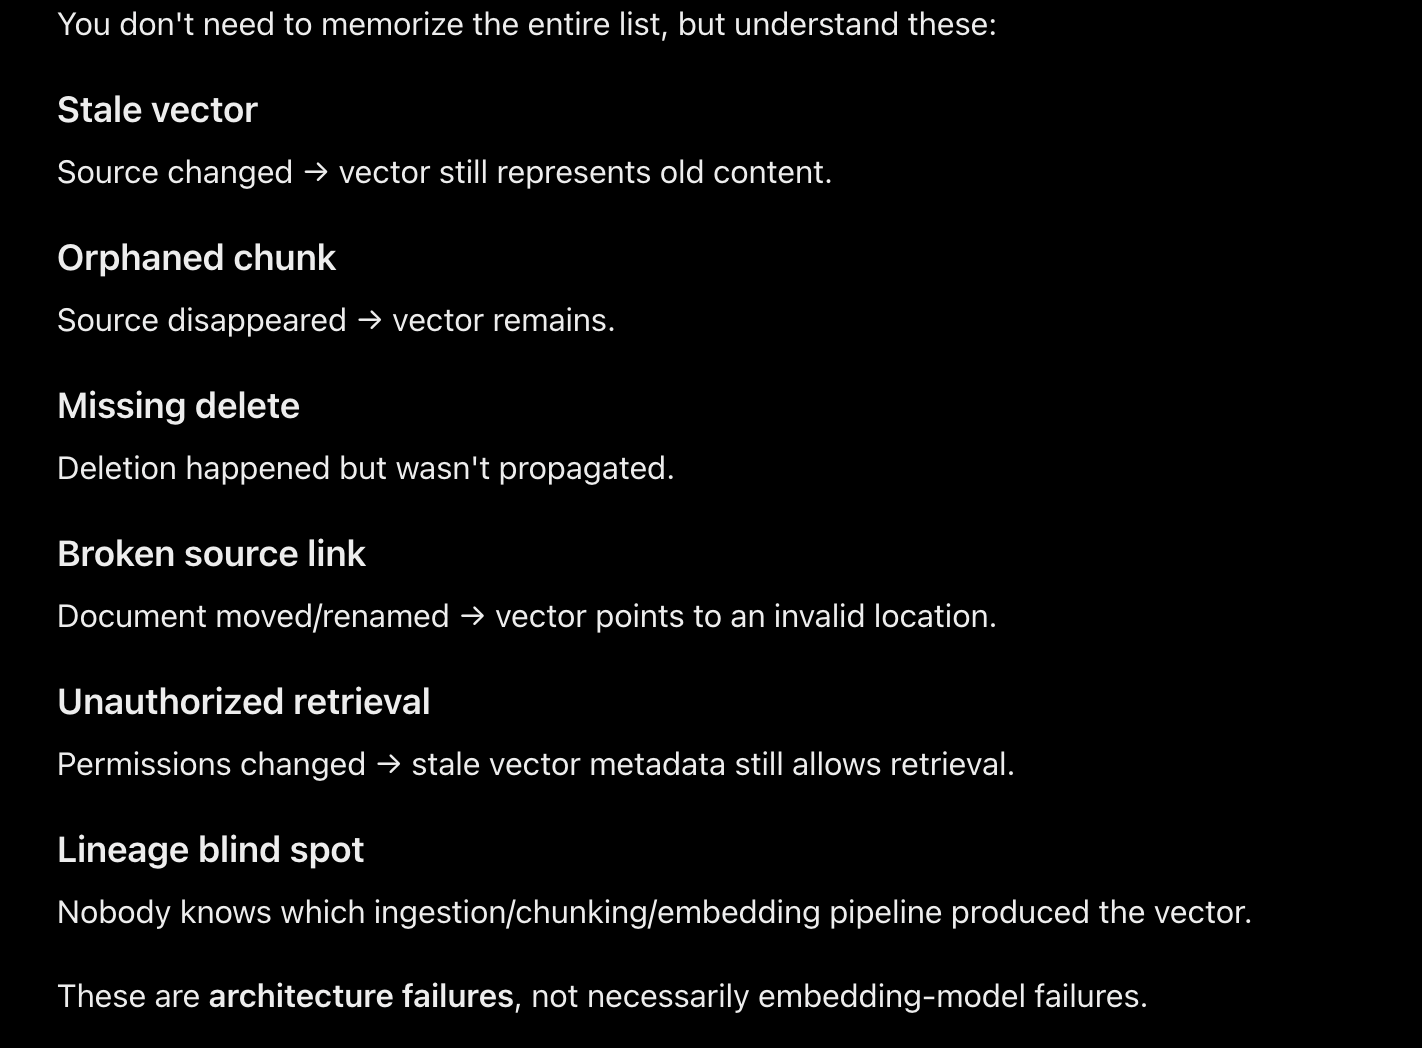


# STORAGE BOUNDARY DEFINED :
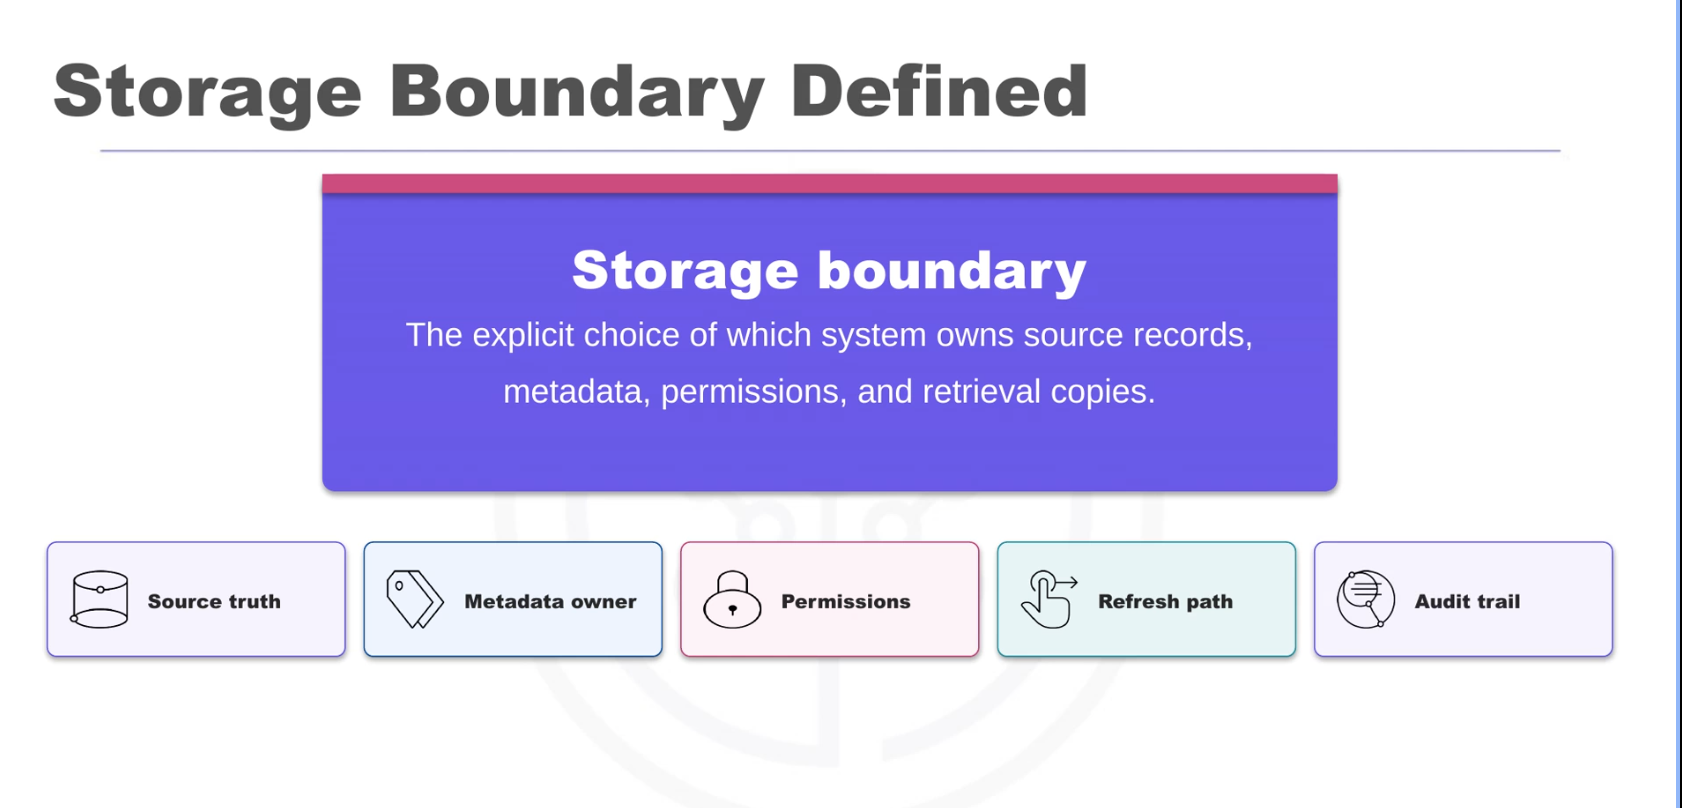
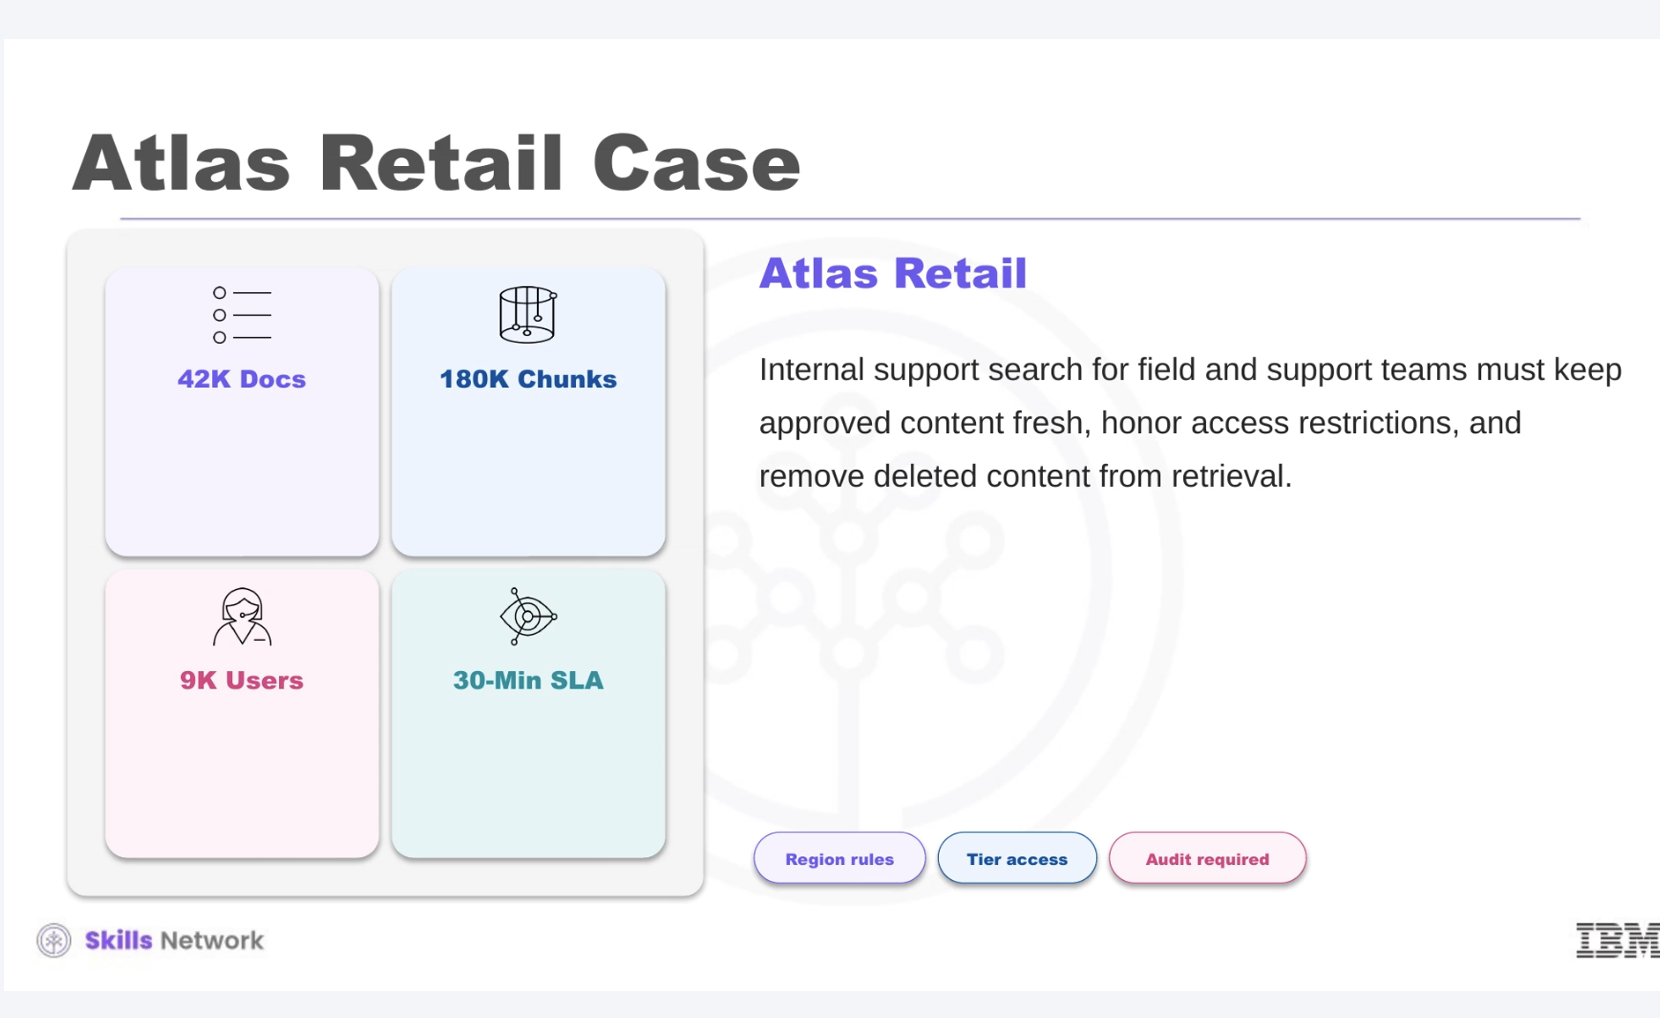
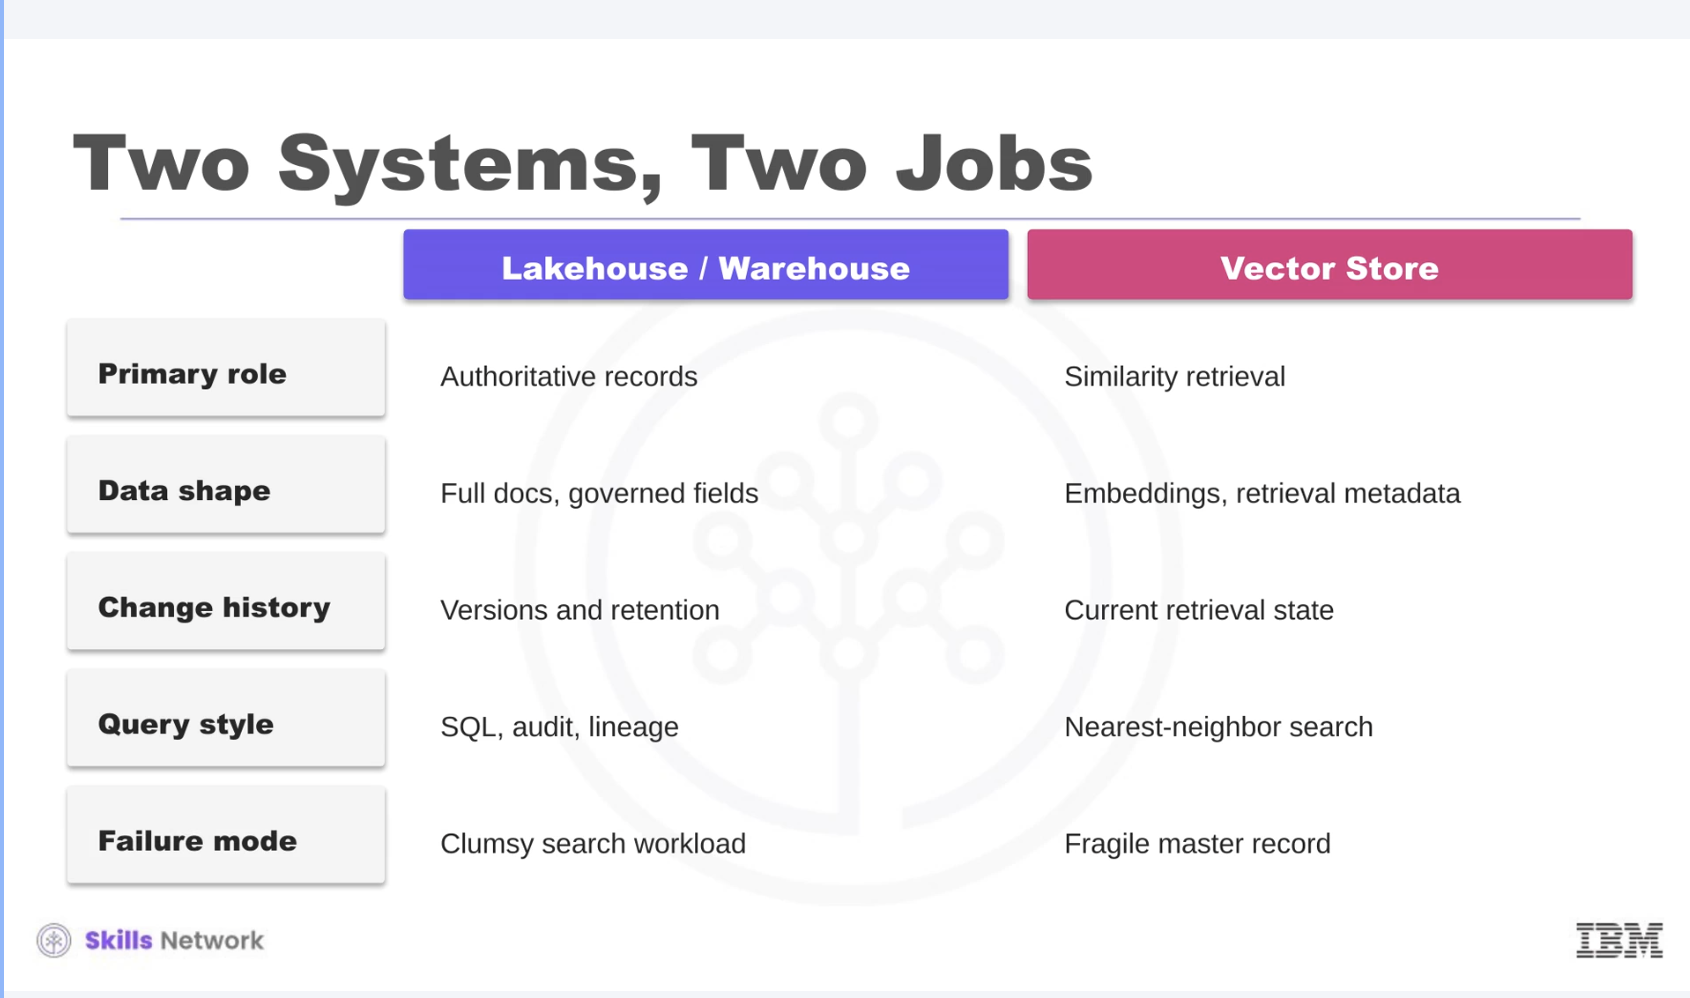
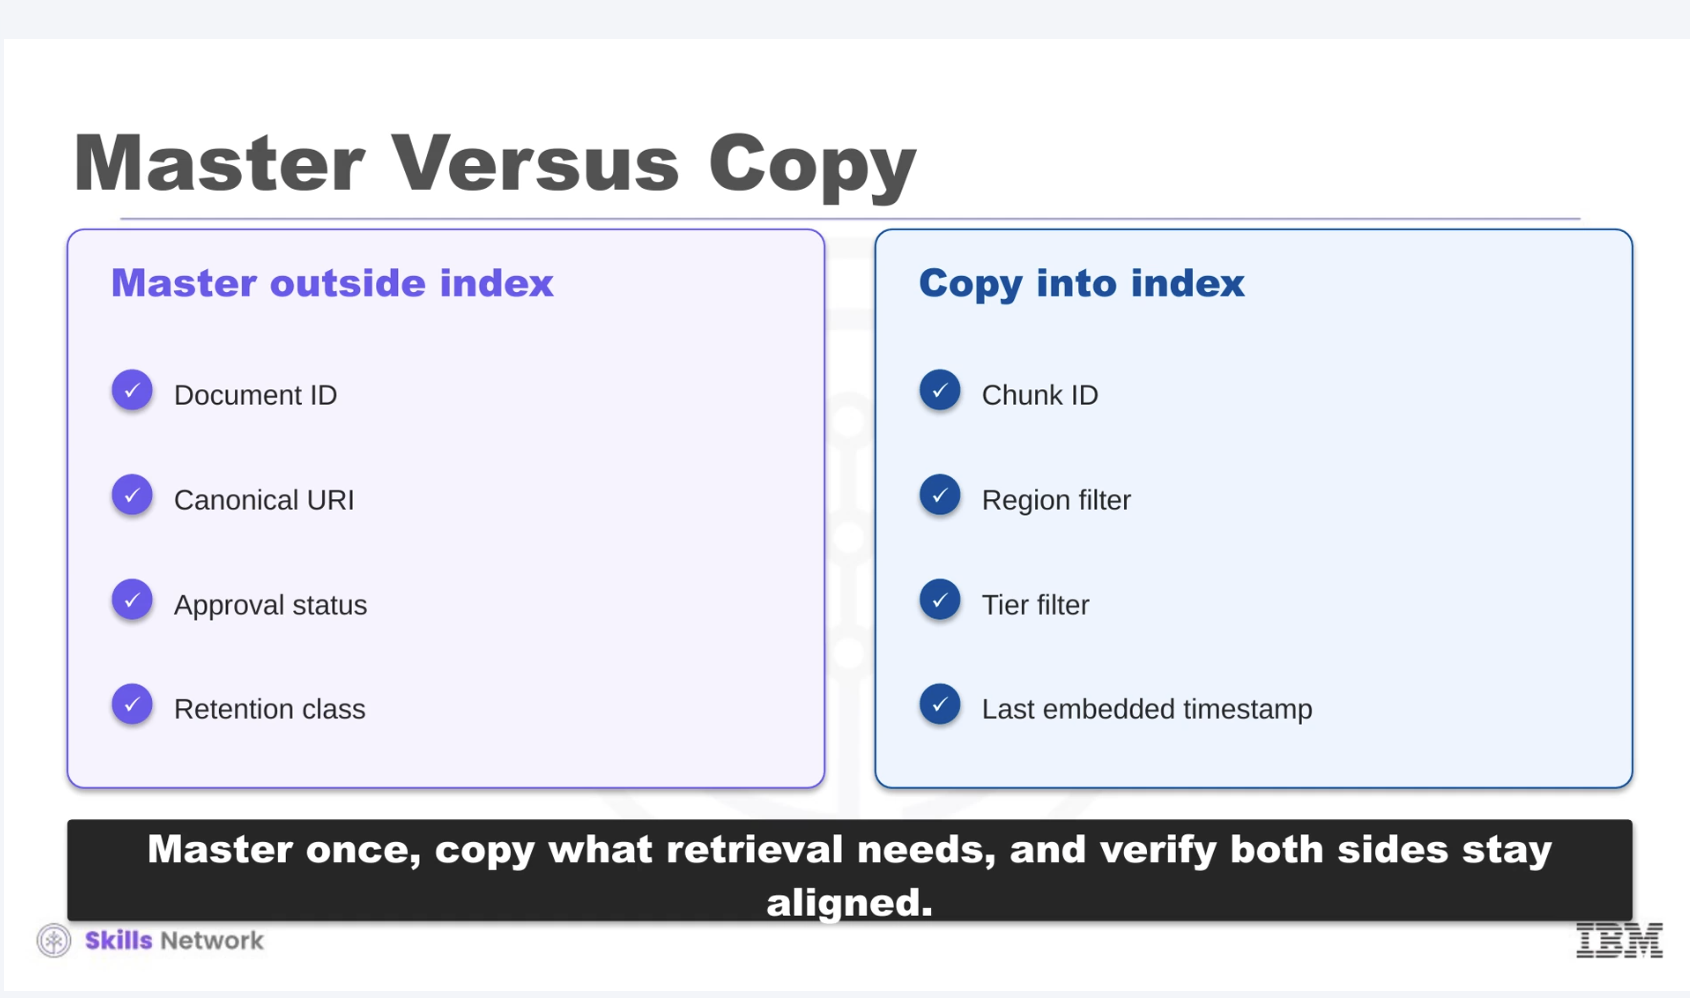
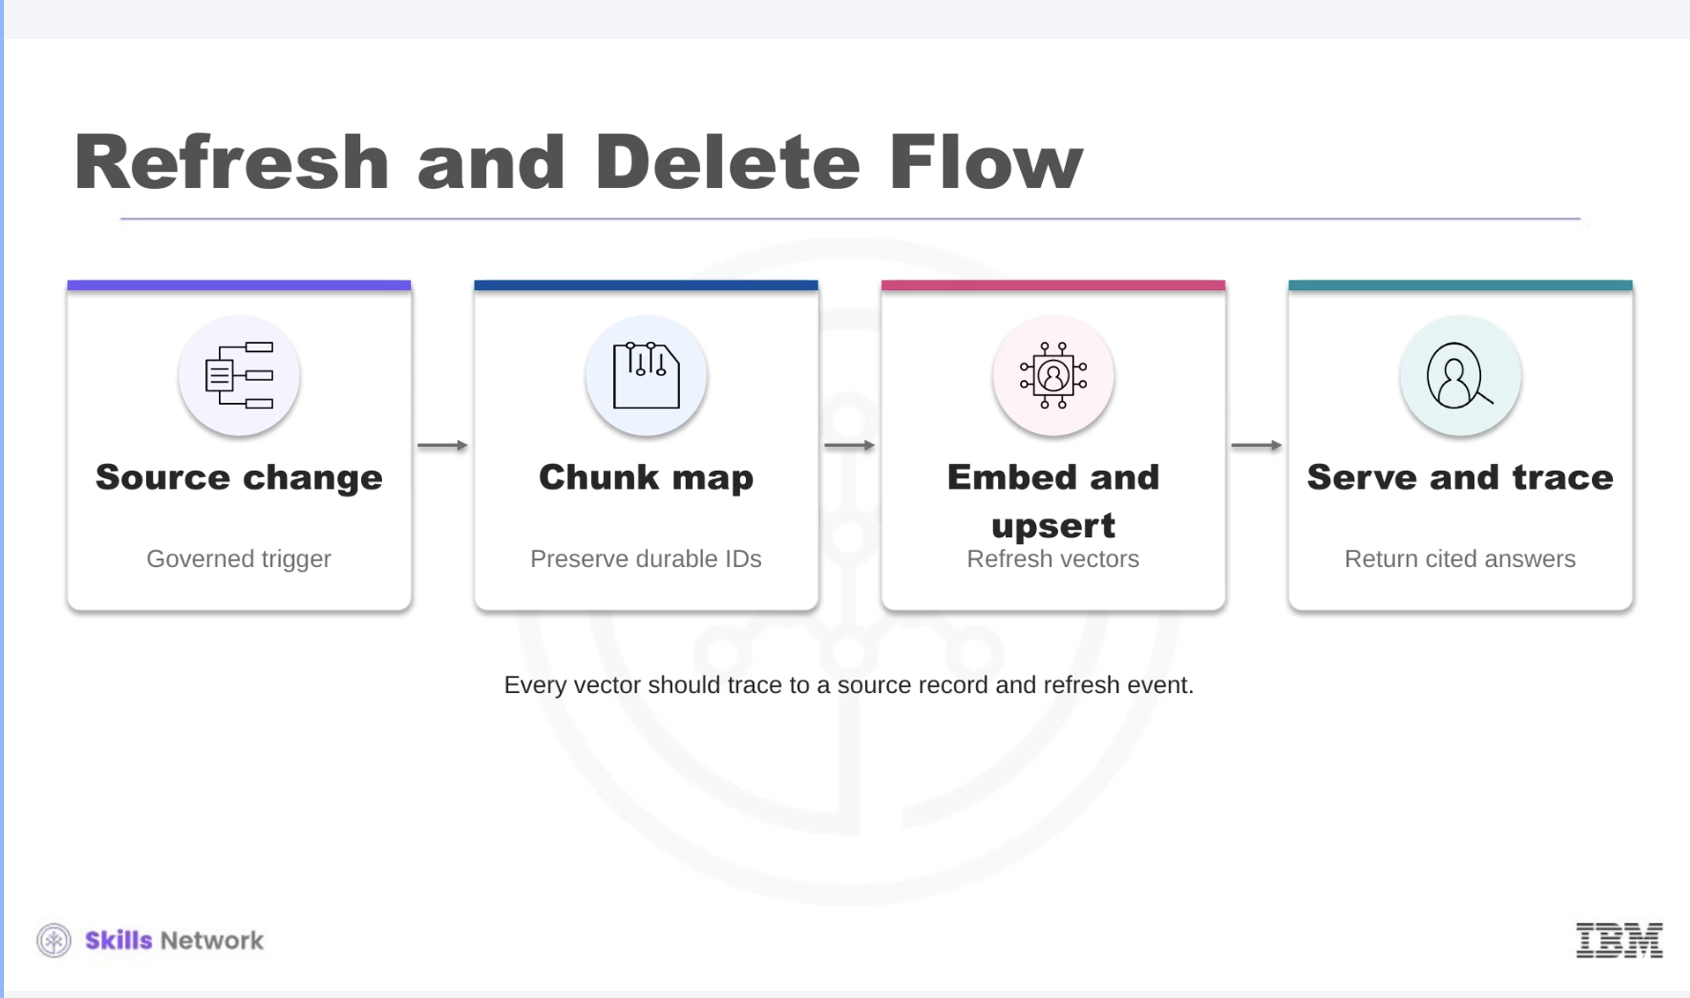
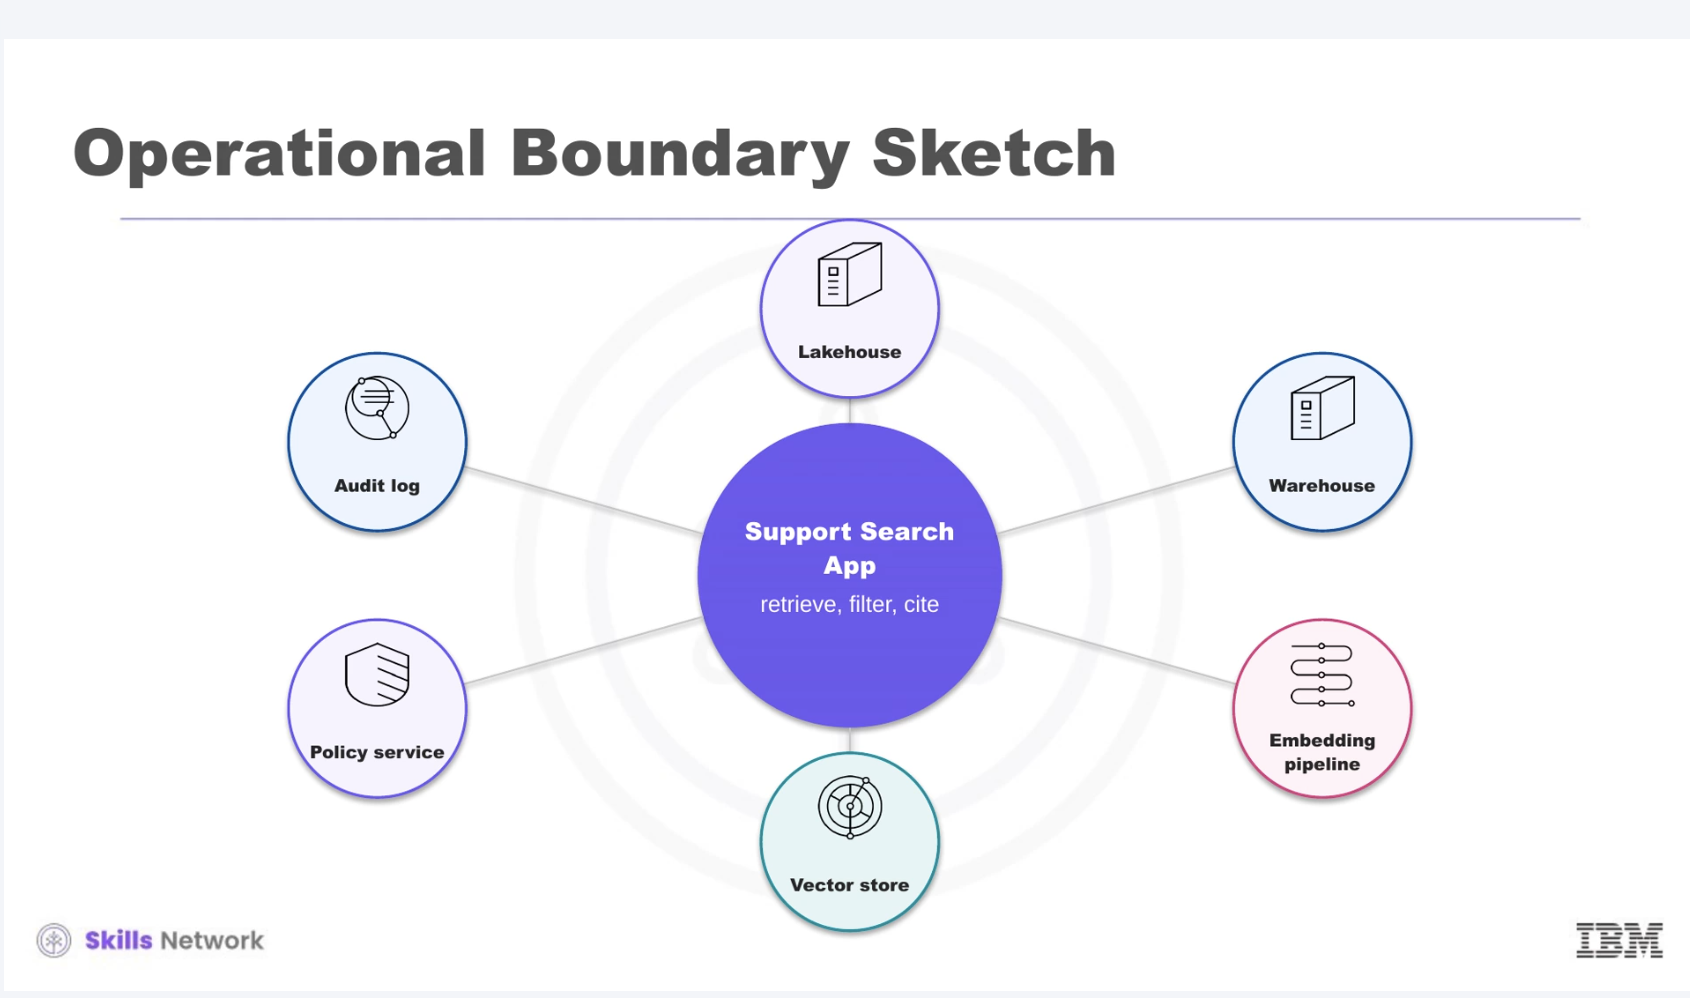
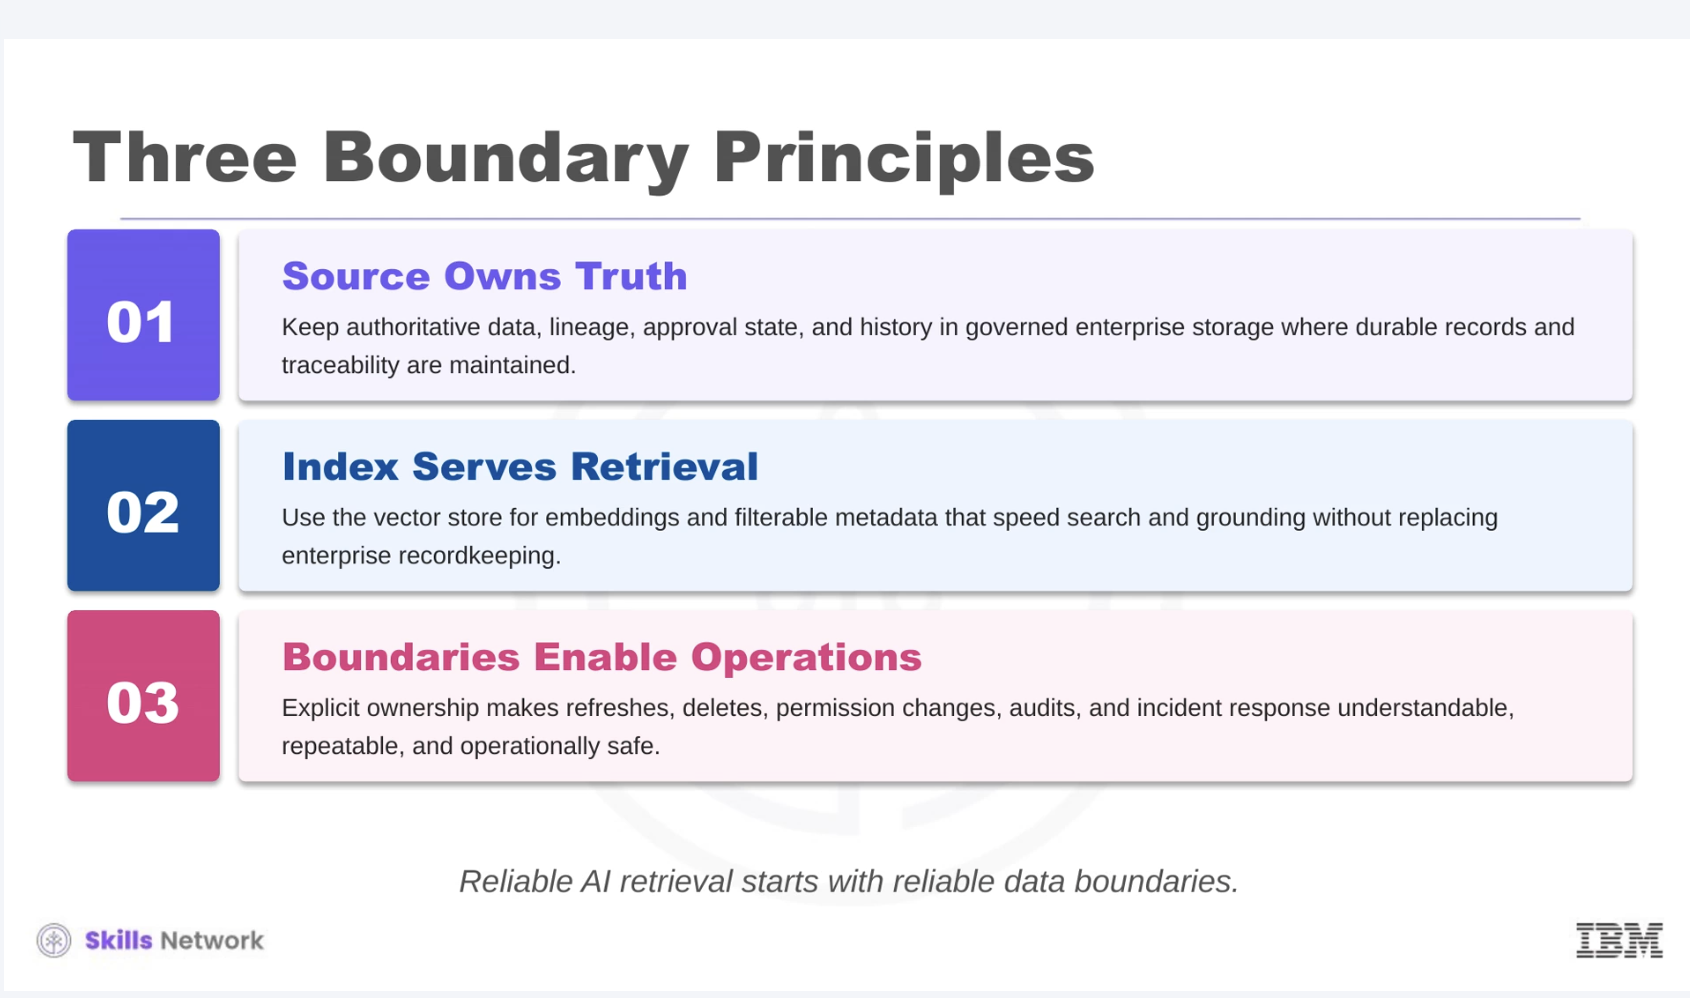
 

# MULTIMODAL DESIGN GOALS
 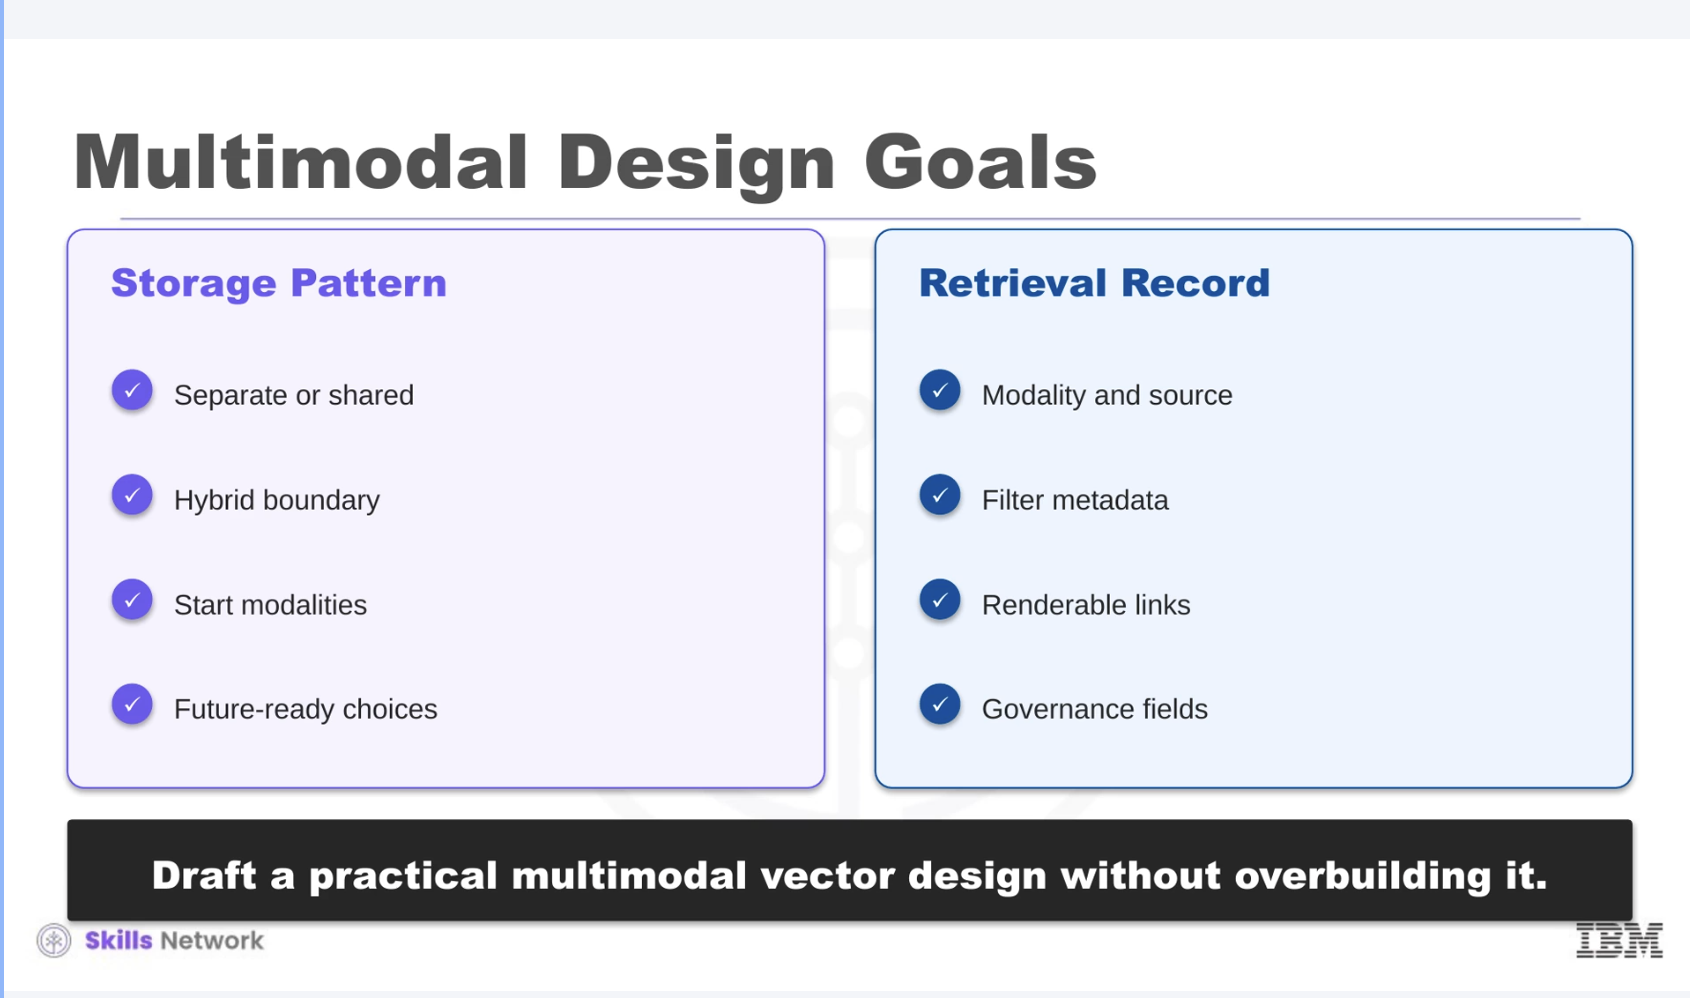
 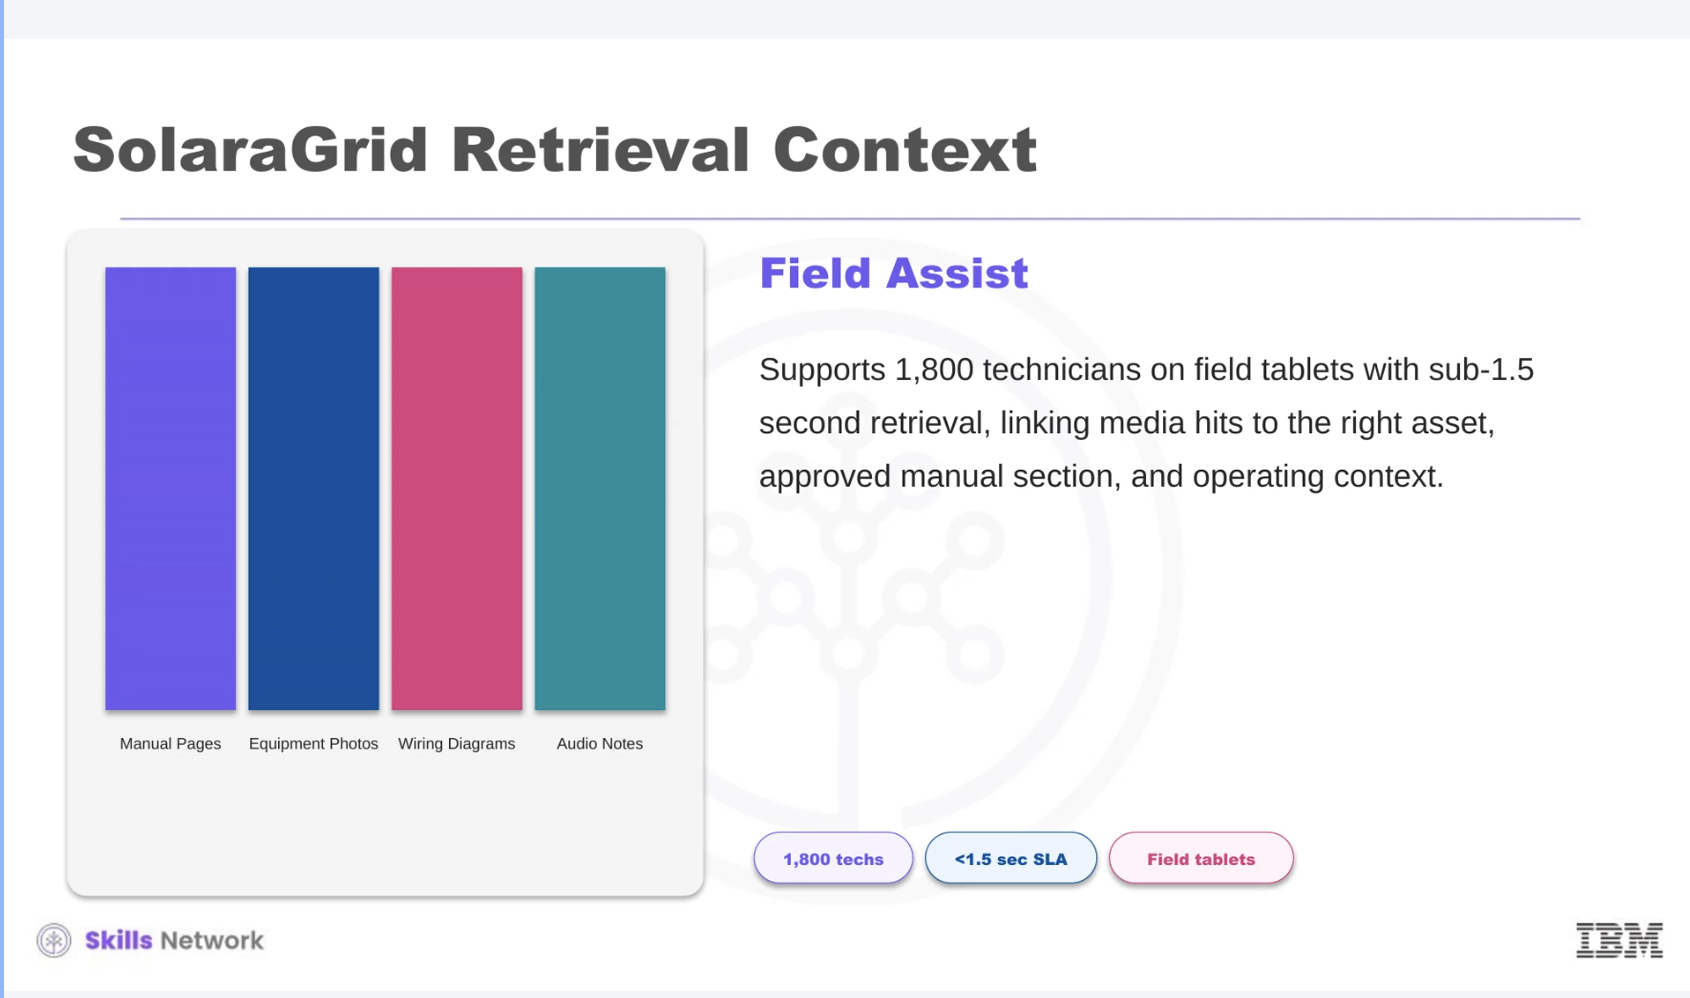
 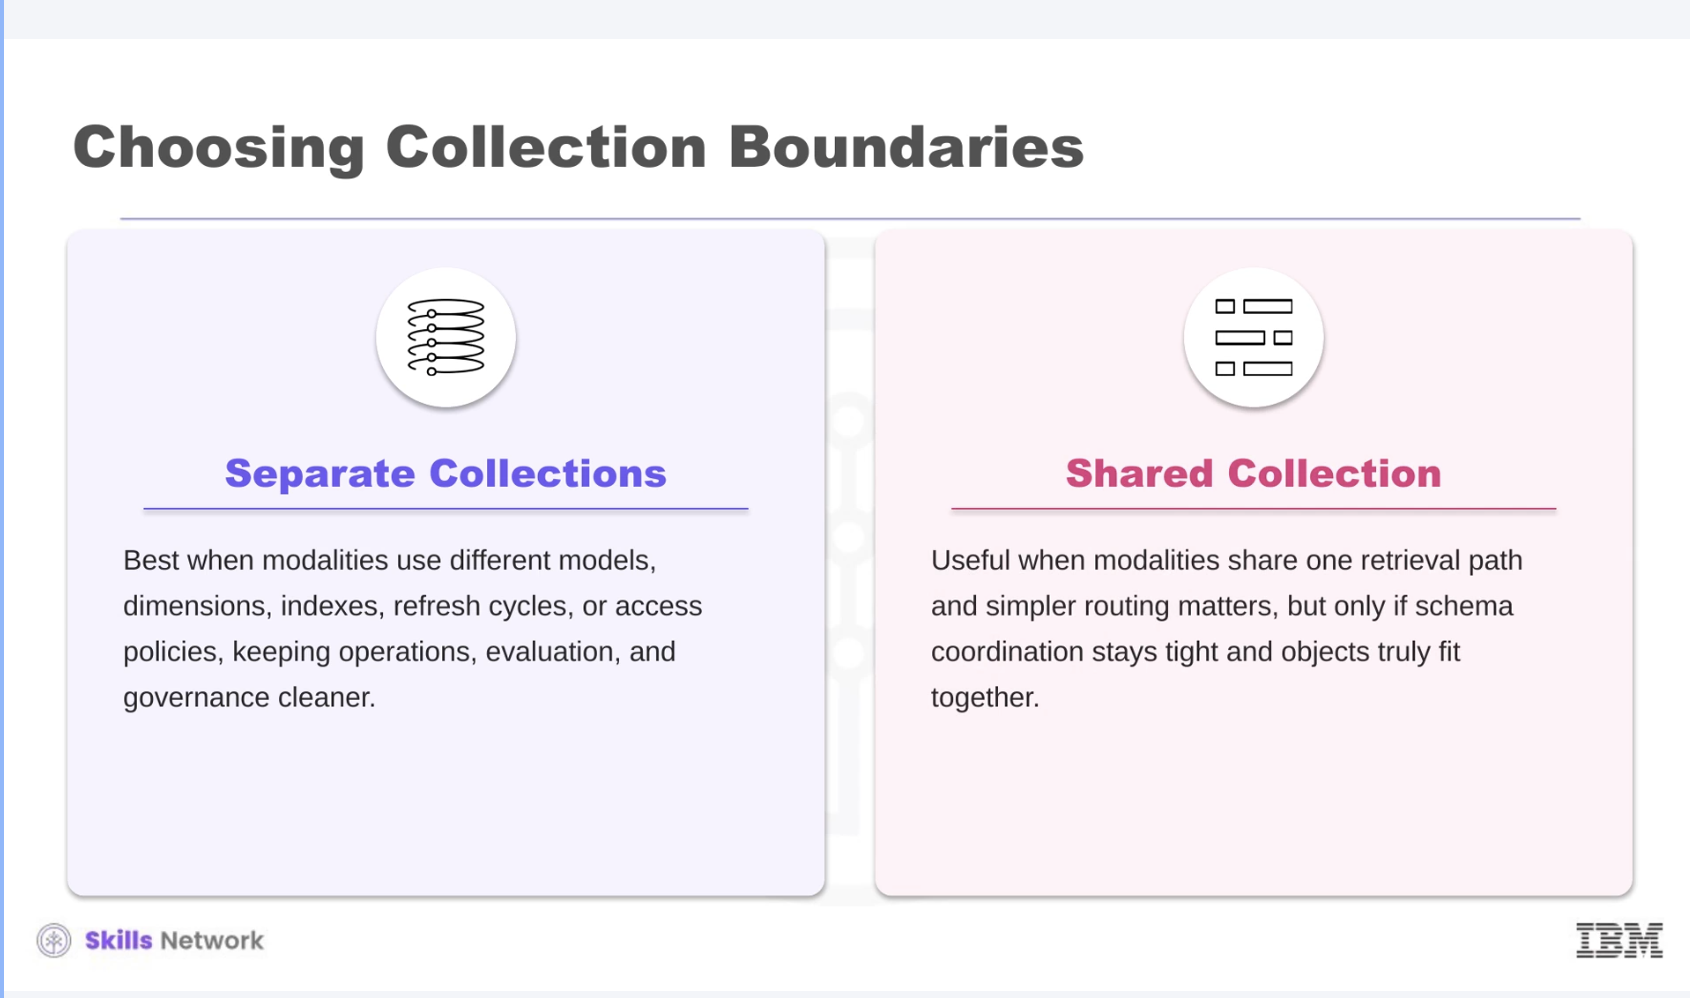
 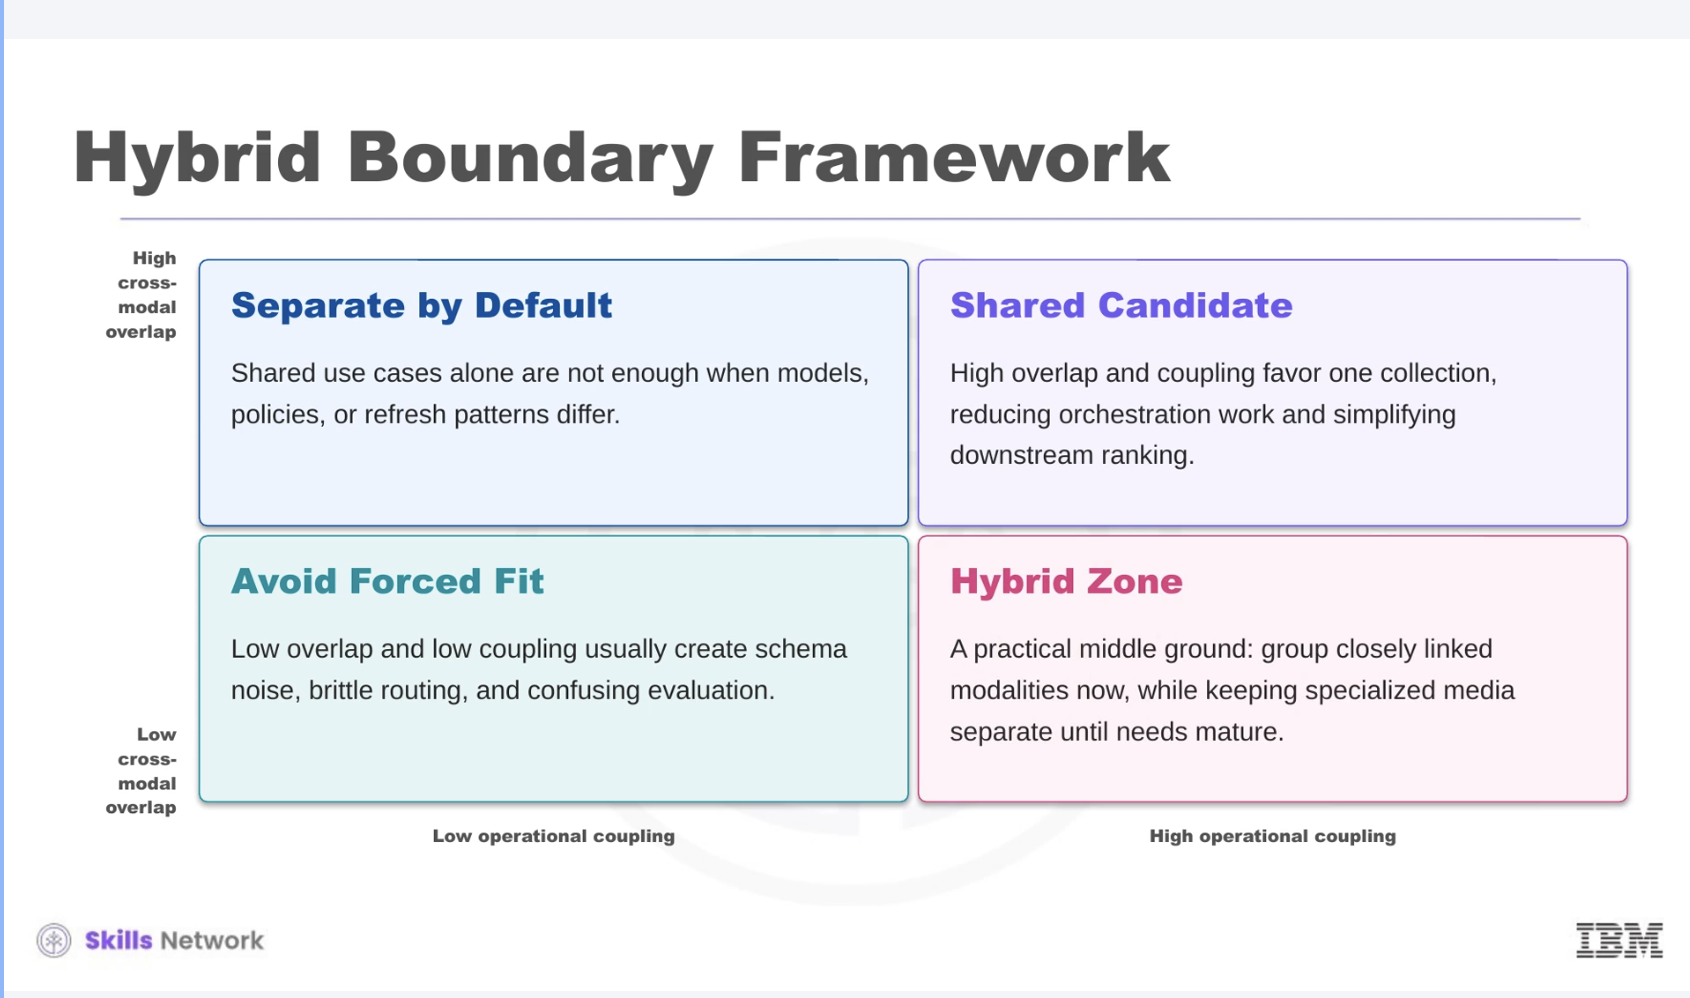
 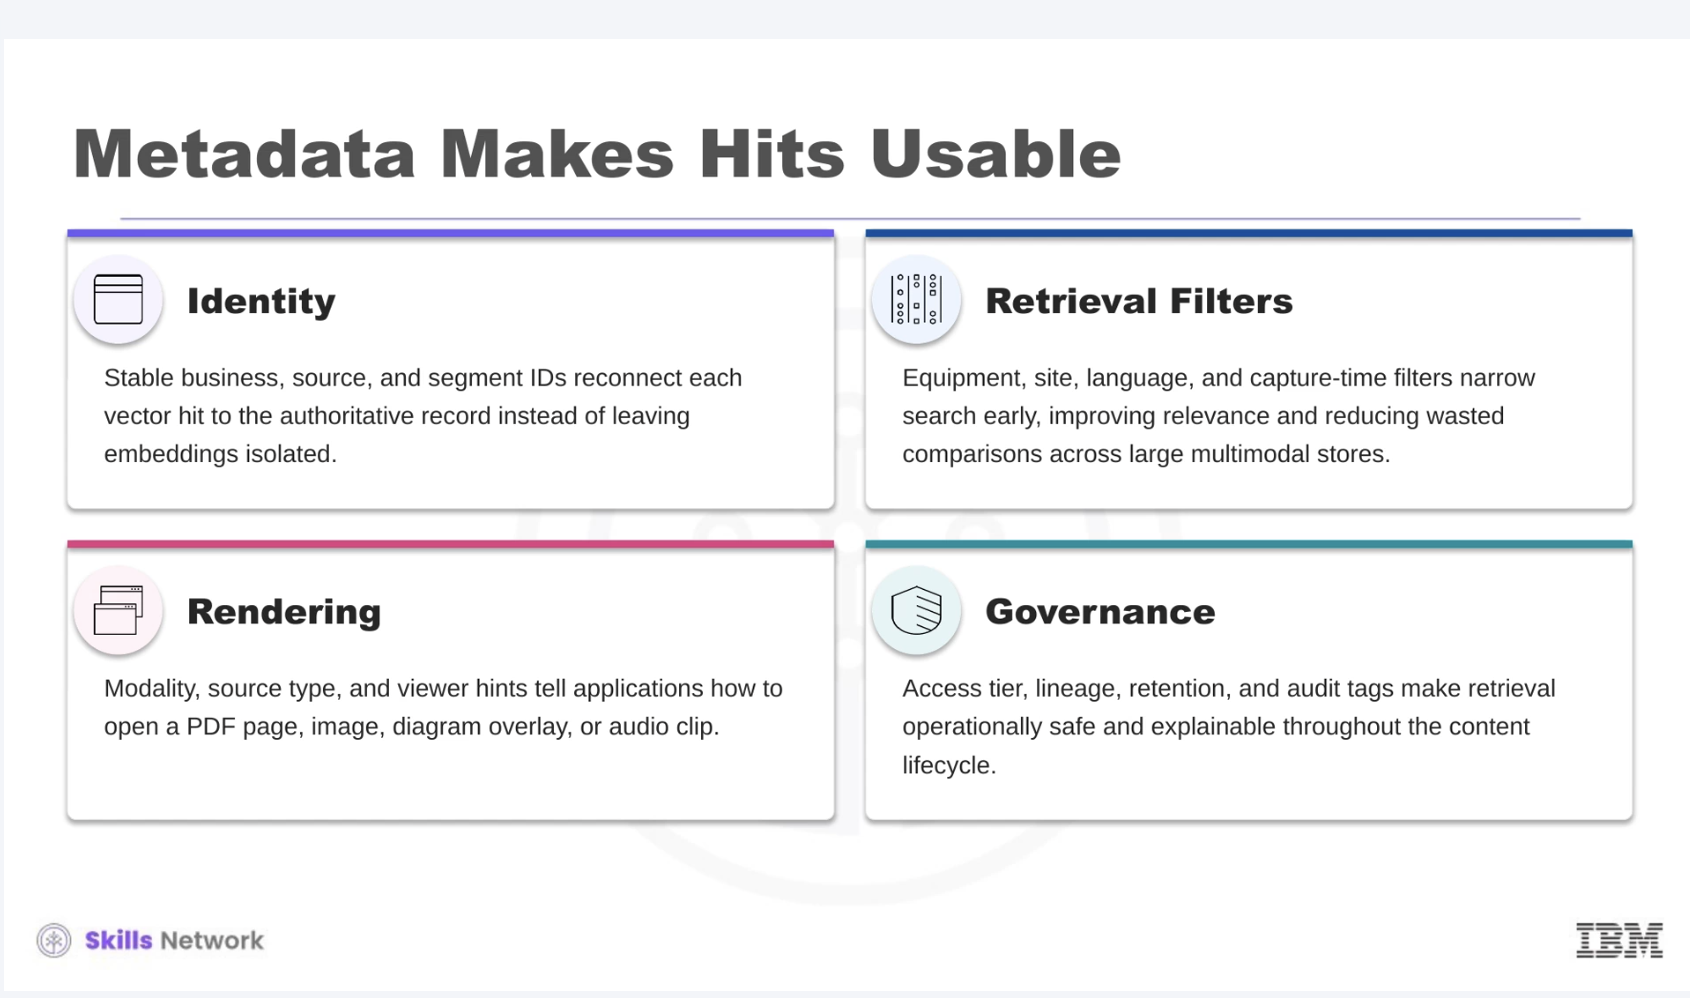
 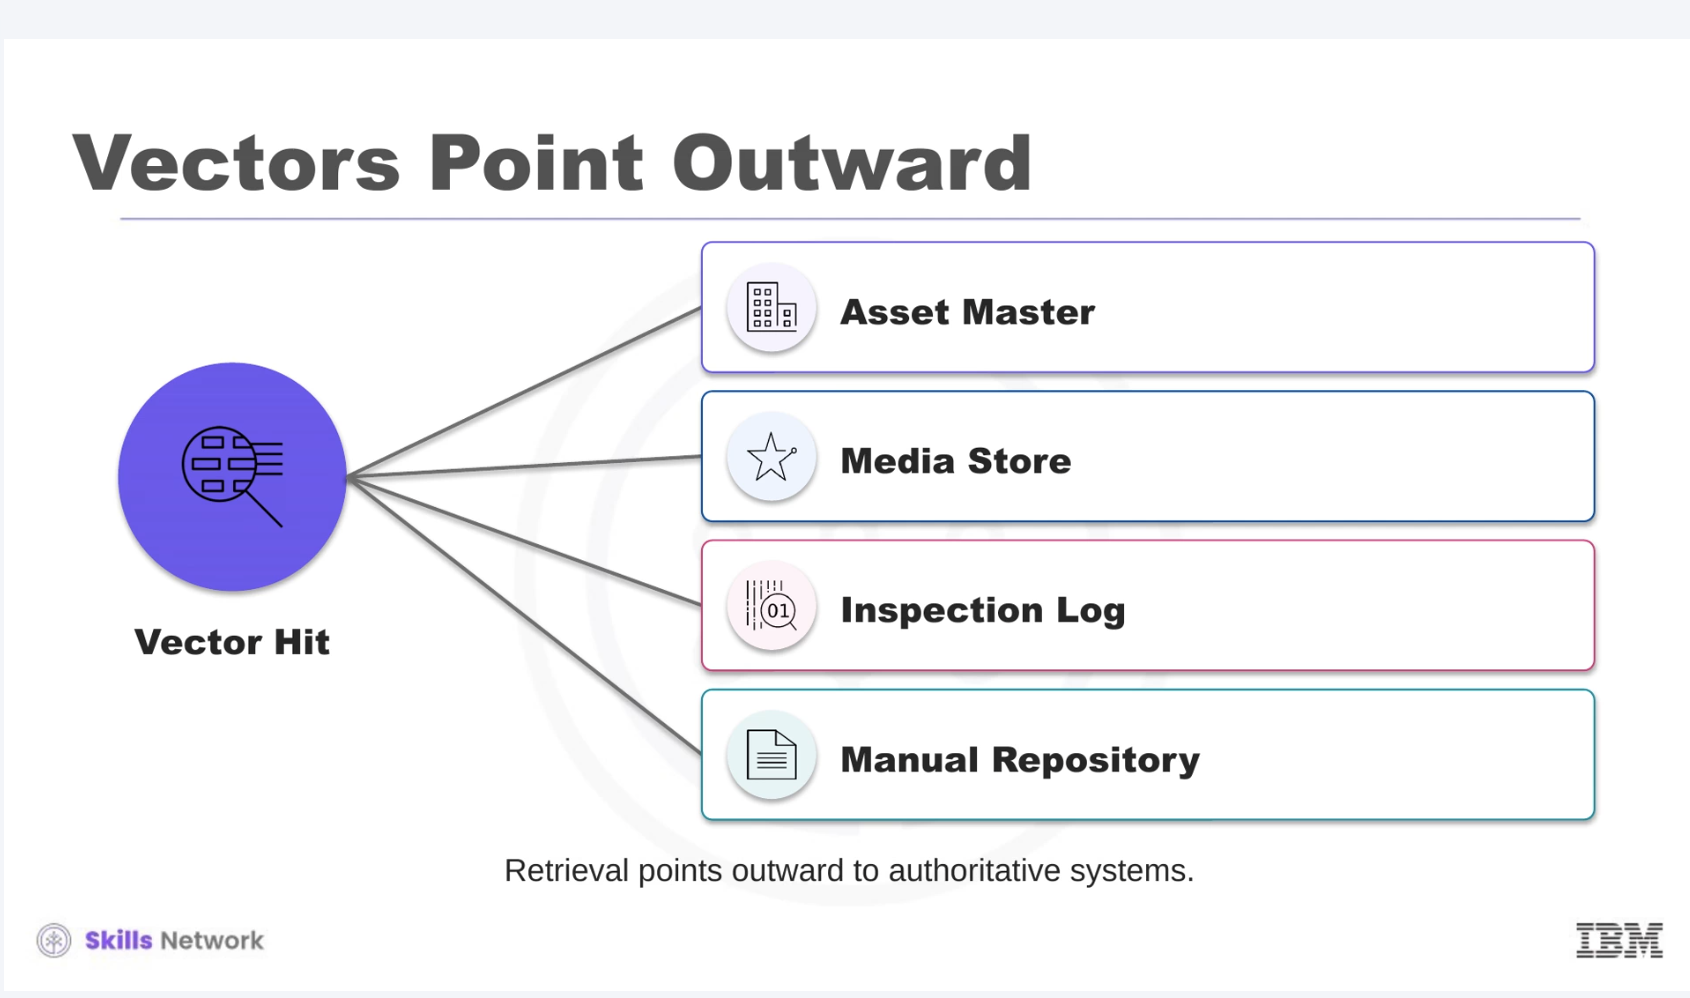
 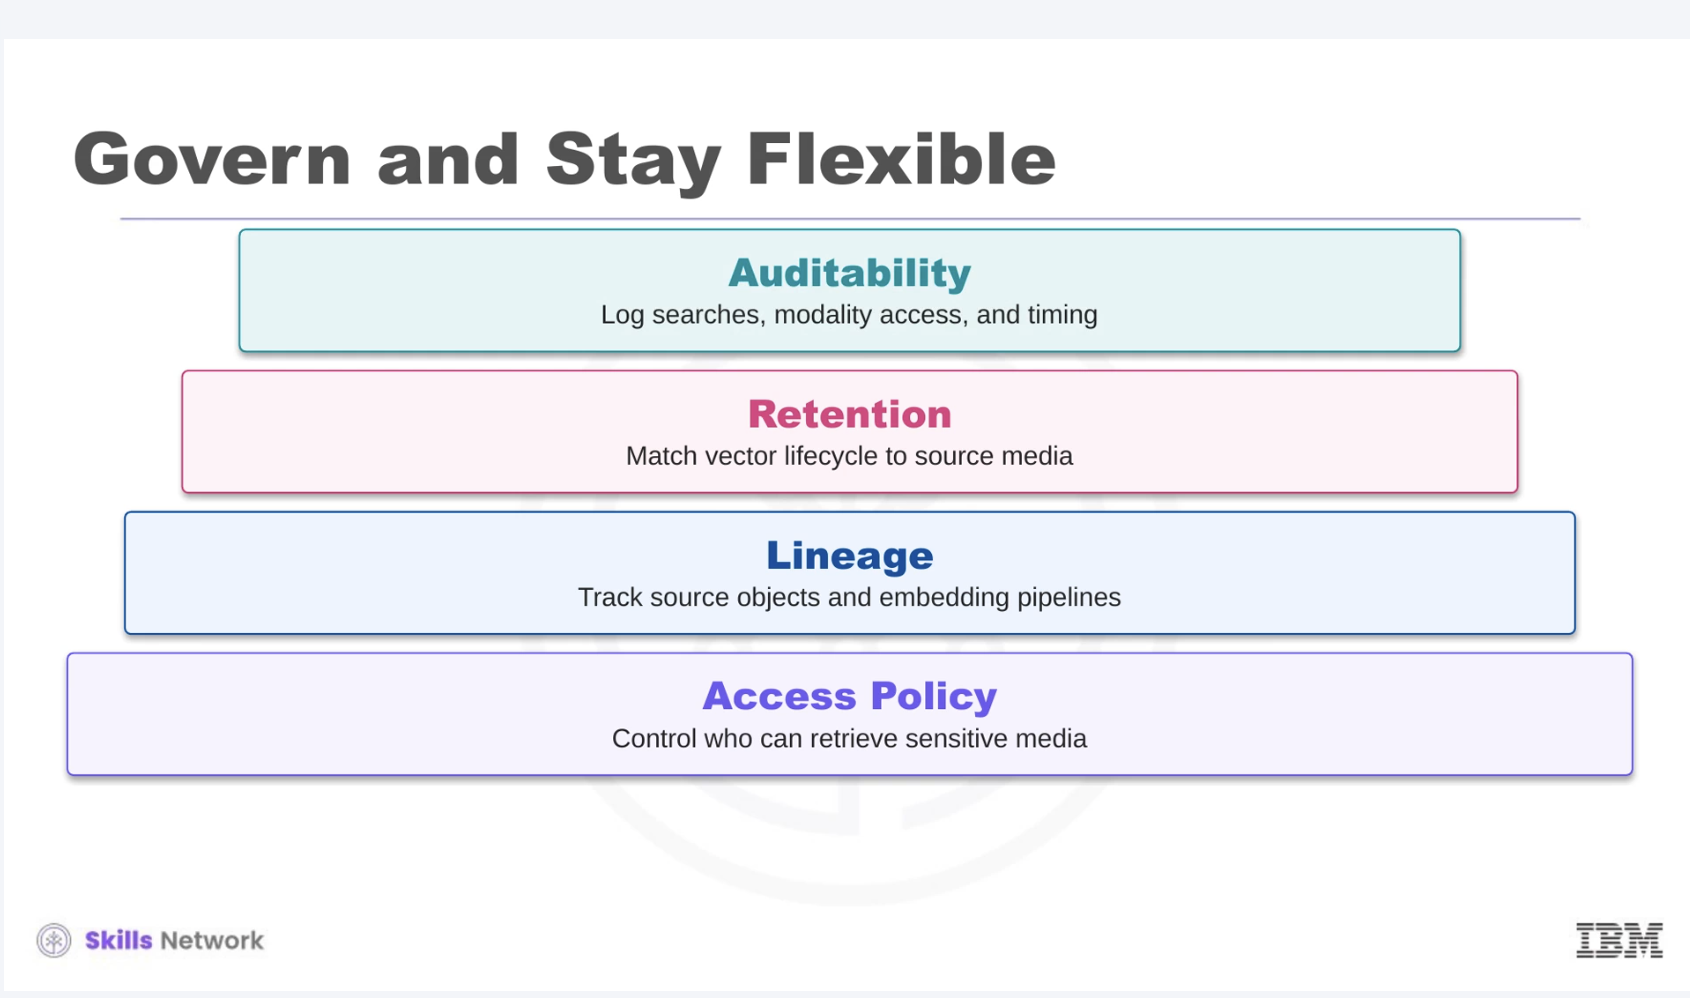
 

# [StoragePattern](StoragePattern/lab1.ipynb)